<a href="https://www.kaggle.com/code/lalit7881/notebooke60e3bb8fc?scriptVersionId=341940444" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/debayank2024/house-price-prediction/modified_data.csv")

In [3]:
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


In [4]:
df.tail()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4595,2014-07-09,308166.67,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,204.08
4596,2014-07-09,534333.33,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,365.98
4597,2014-07-09,416904.17,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,138.51
4598,2014-07-10,203400.00,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,97.32
4599,2014-07-10,220600.00,3.0,2.50,1490,8102,2.0,0,0,4,1490,0,1990,0,18717 SE 258th St,Covington,WA 98042,148.05


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [6]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [7]:
df.isnull().sum()

date              0
price             0
bedrooms          0
bathrooms         0
sqft_living       0
sqft_lot          0
floors            0
waterfront        0
view              0
condition         0
sqft_above        0
sqft_basement     0
yr_built          0
yr_renovated      0
street            0
city              0
statezip          0
price_per_sqft    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'price_per_sqft'],
      dtype='object')

In [10]:
df.nunique()

date                70
price             1741
bedrooms            10
bathrooms           26
sqft_living        566
sqft_lot          3113
floors               6
waterfront           2
view                 5
condition            5
sqft_above         511
sqft_basement      207
yr_built           115
yr_renovated        60
street            4525
city                44
statezip            77
price_per_sqft    4005
dtype: int64

In [11]:
df.dtypes

date               object
price             float64
bedrooms          float64
bathrooms         float64
sqft_living         int64
sqft_lot            int64
floors            float64
waterfront          int64
view                int64
condition           int64
sqft_above          int64
sqft_basement       int64
yr_built            int64
yr_renovated        int64
street             object
city               object
statezip           object
price_per_sqft    float64
dtype: object

In [12]:
df.shape

(4600, 18)

## EDA

DATASET LOADED SUCCESSFULLY

First 5 Rows:
         date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0  2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1  2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2  2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3  2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4  2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370            280      1921   
2           0     0          4        1930              0      1966   
3           0     0          4        1000           1000      1963   
4           0     0          4        1140            800      1976   

   yr_renovated                    street       c

<Figure size 1400x600 with 0 Axes>

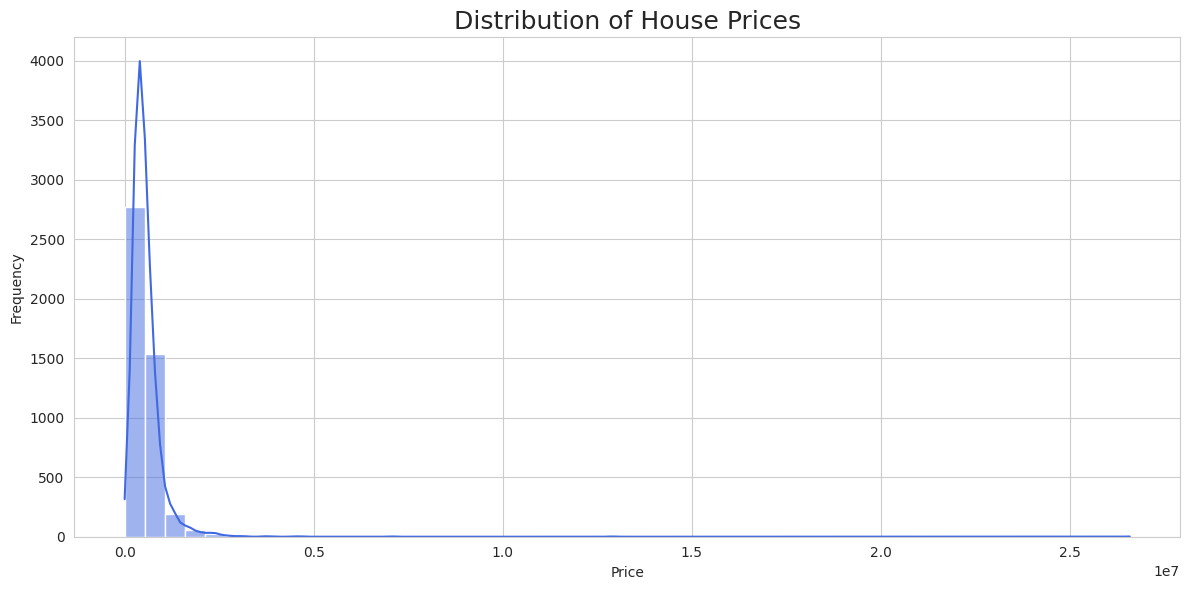

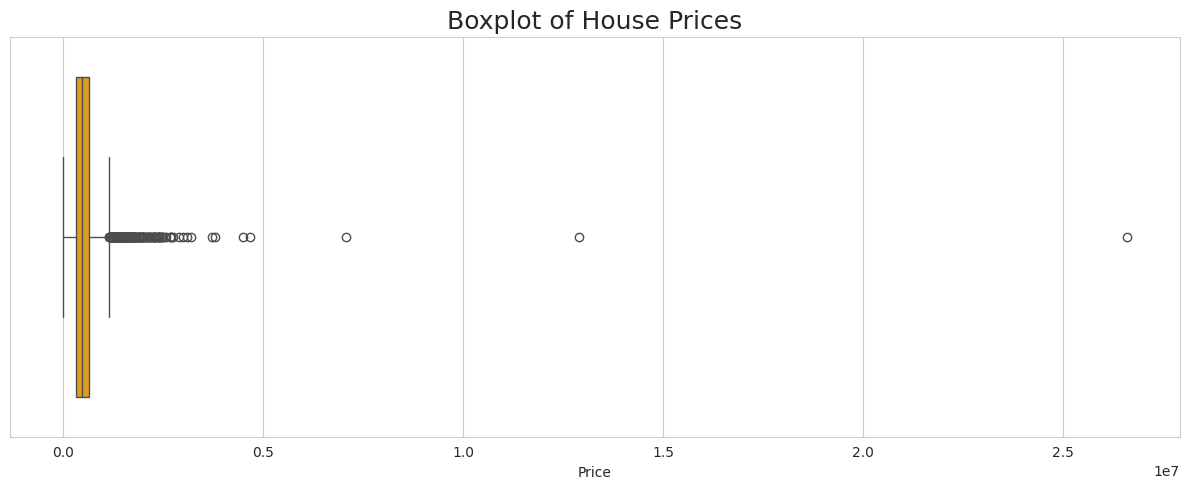

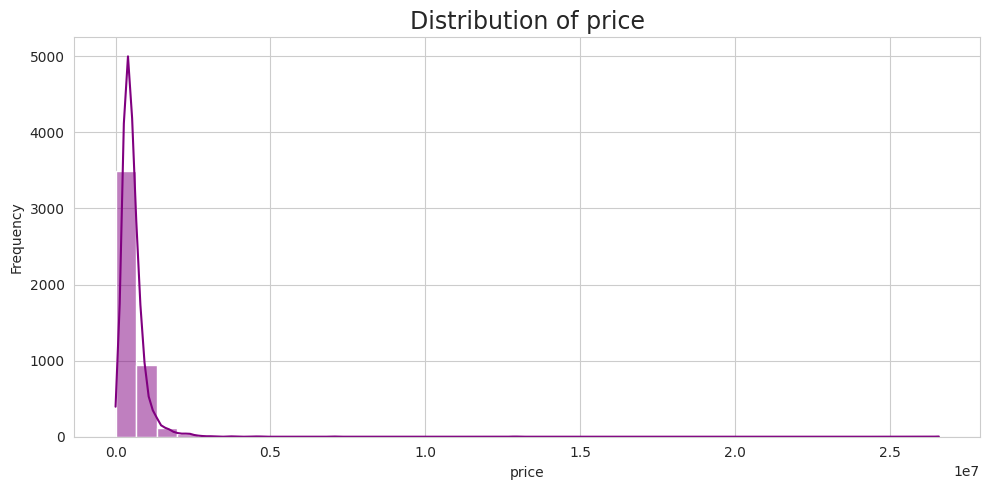

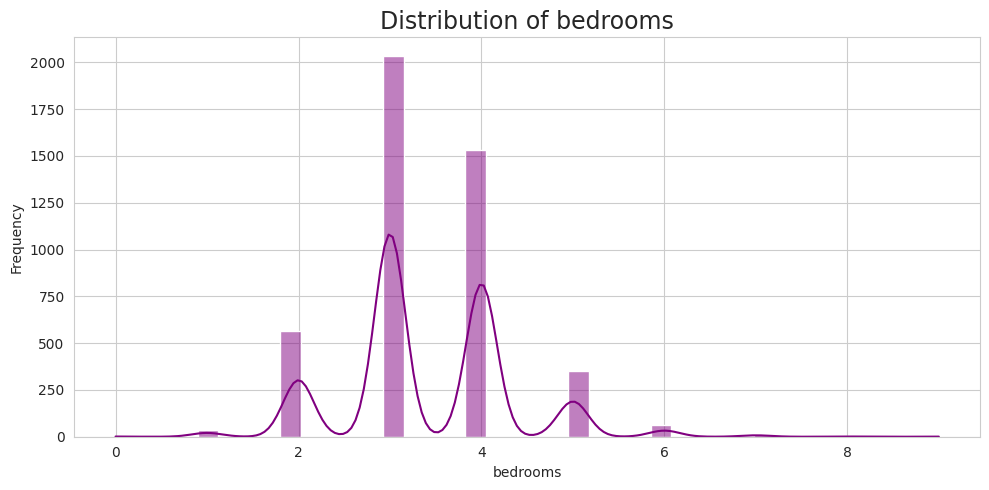

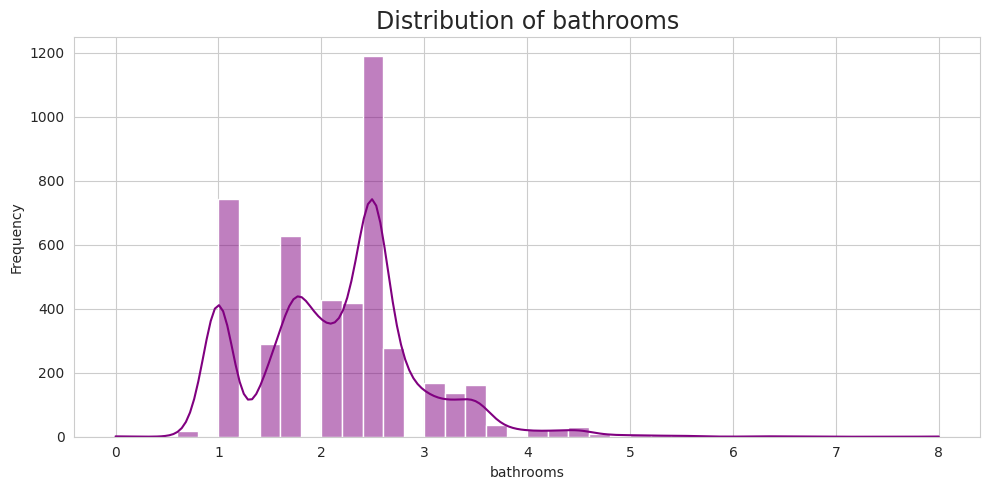

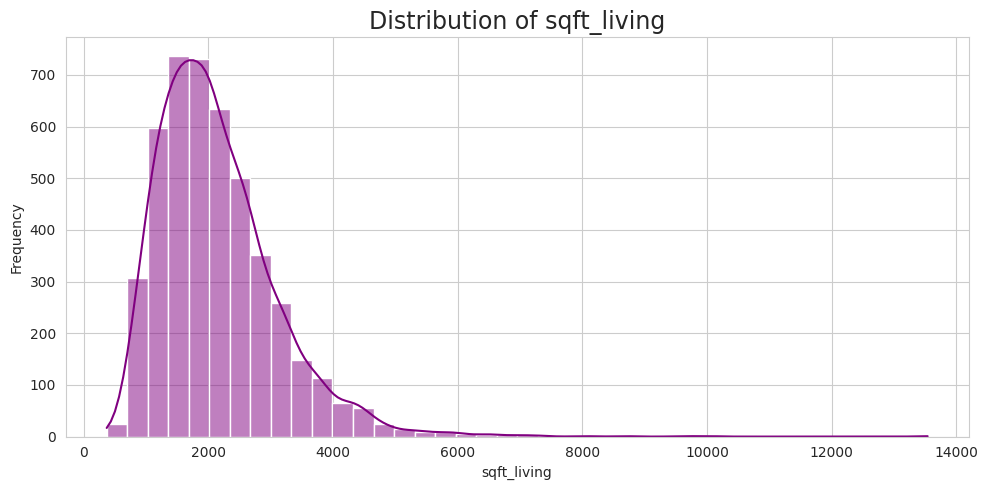

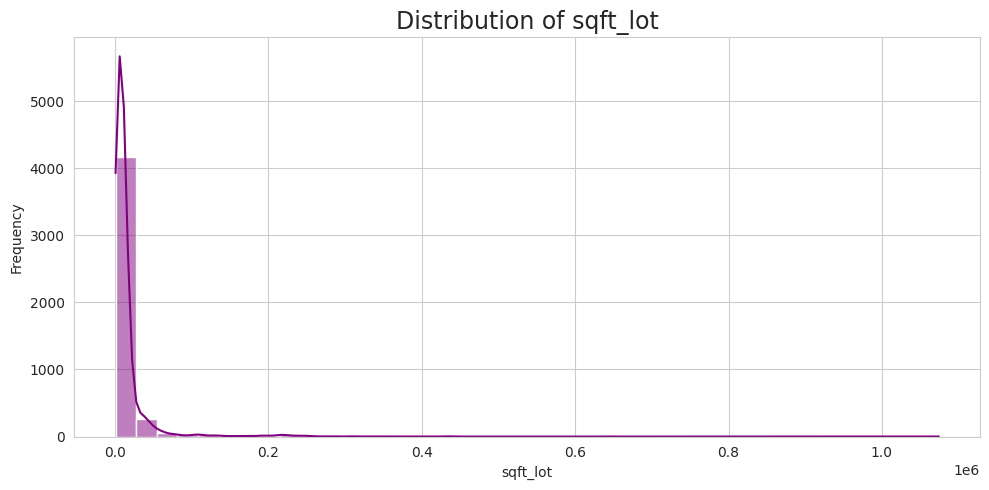

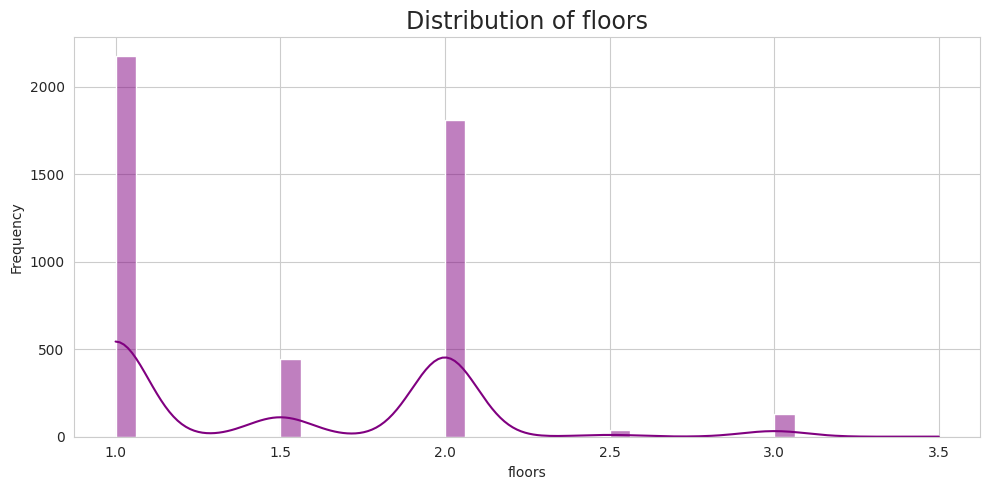

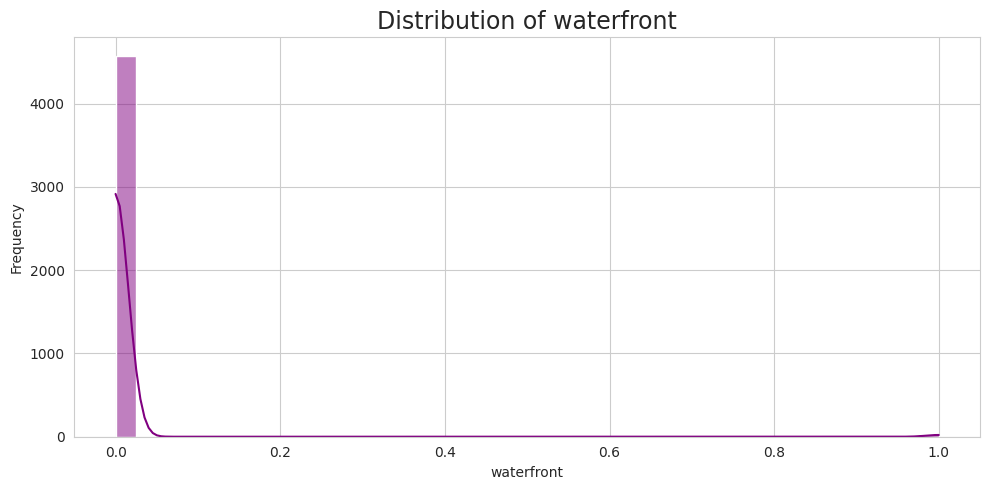

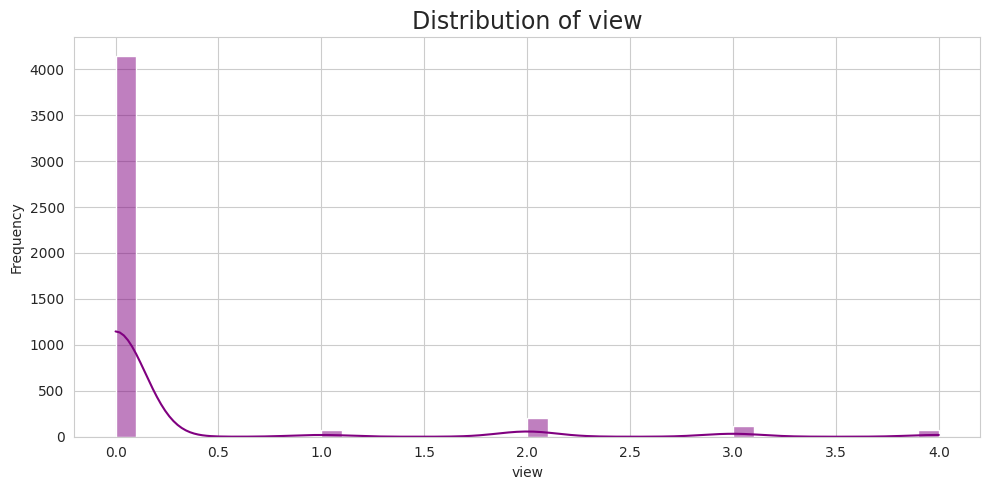

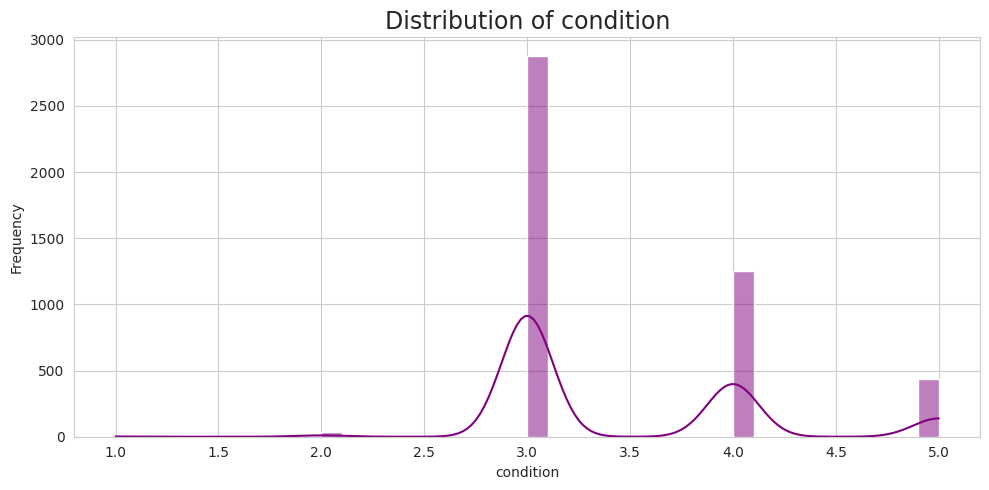

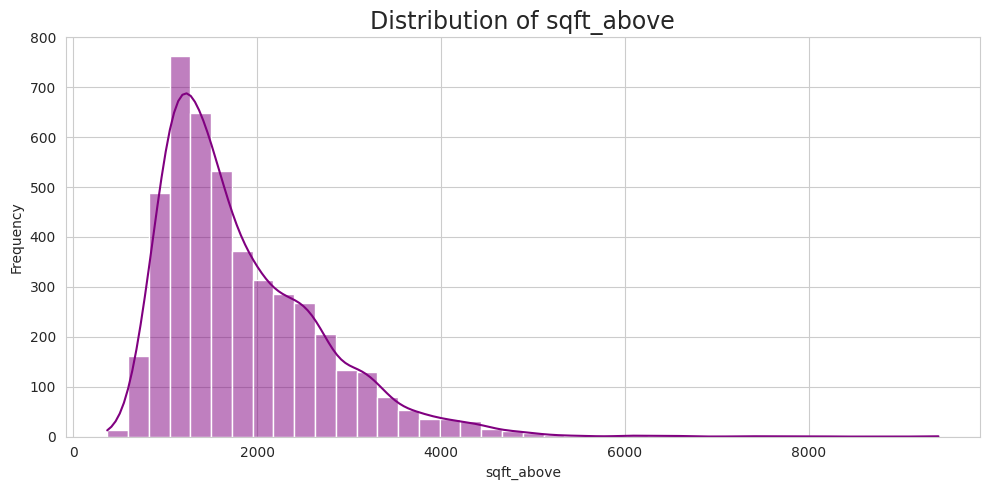

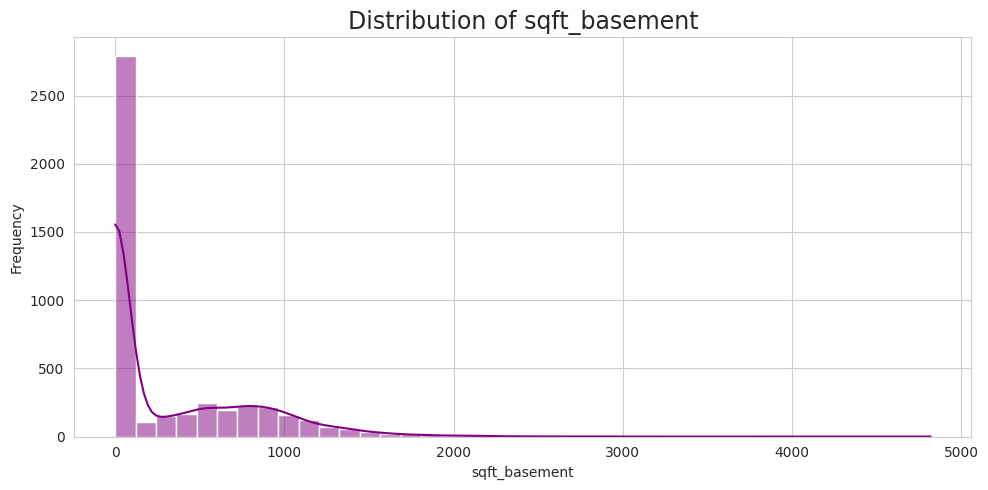

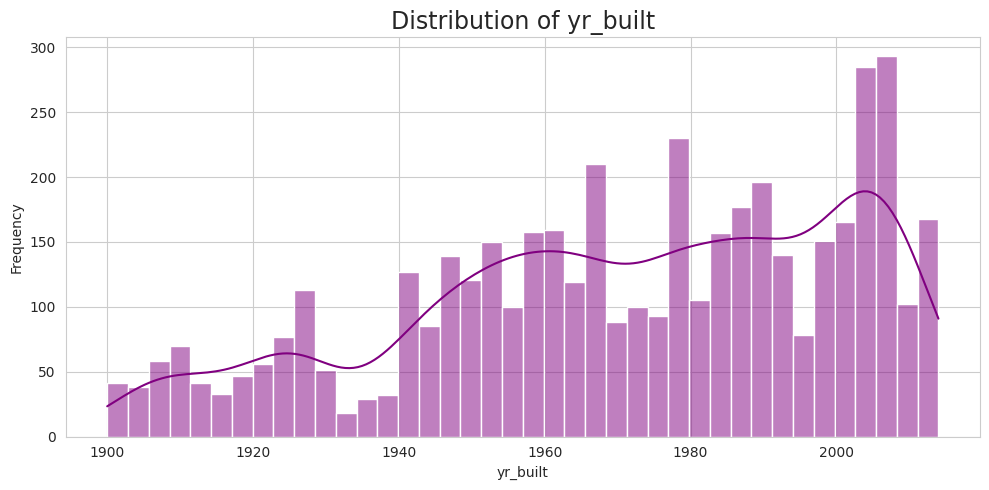

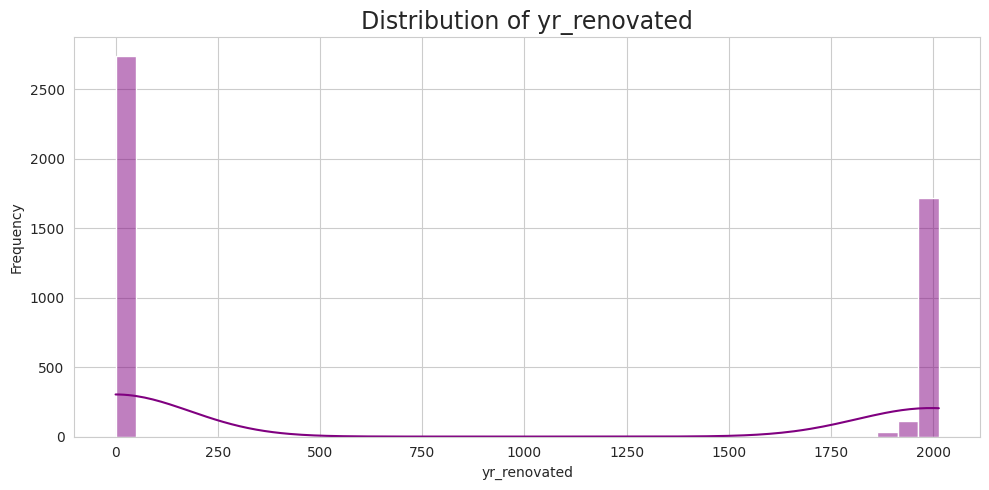

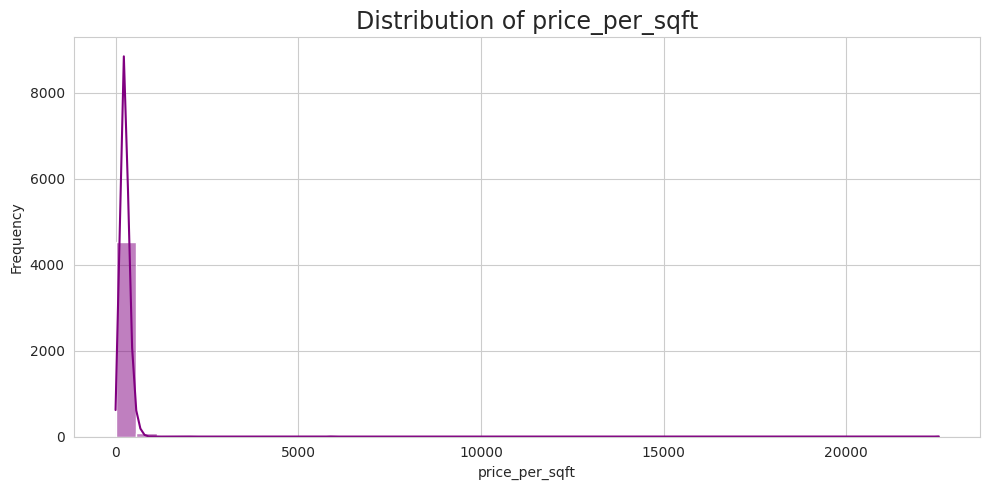

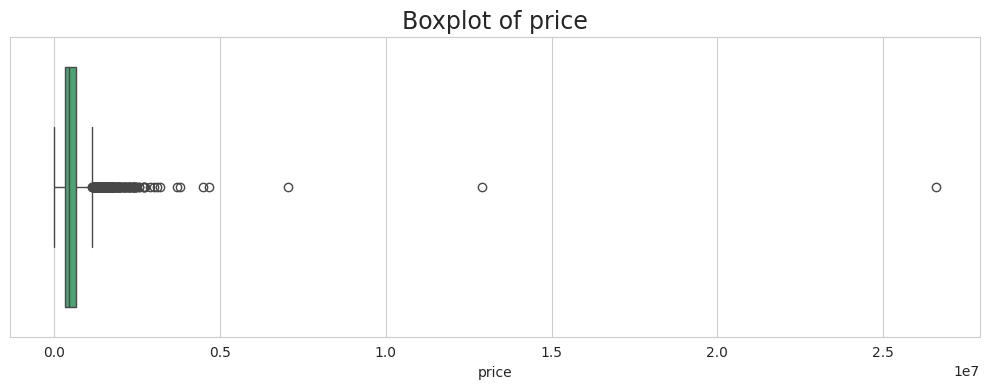

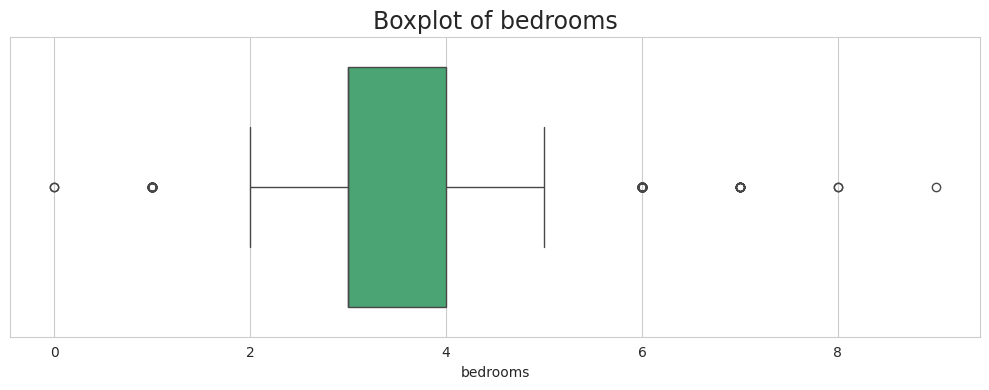

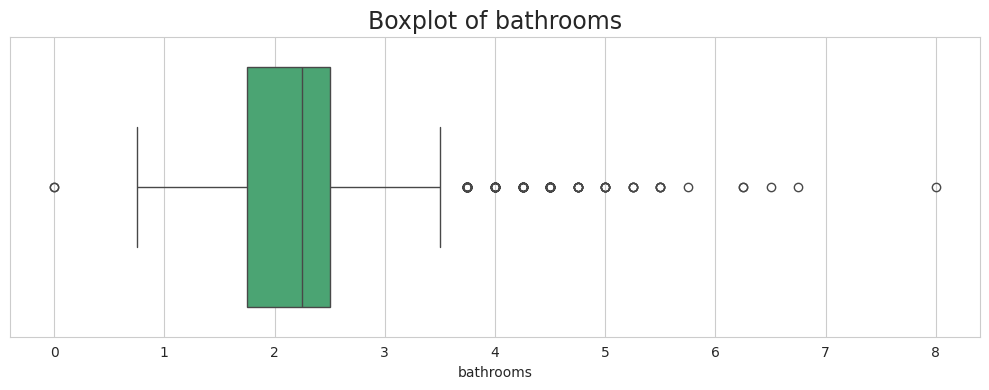

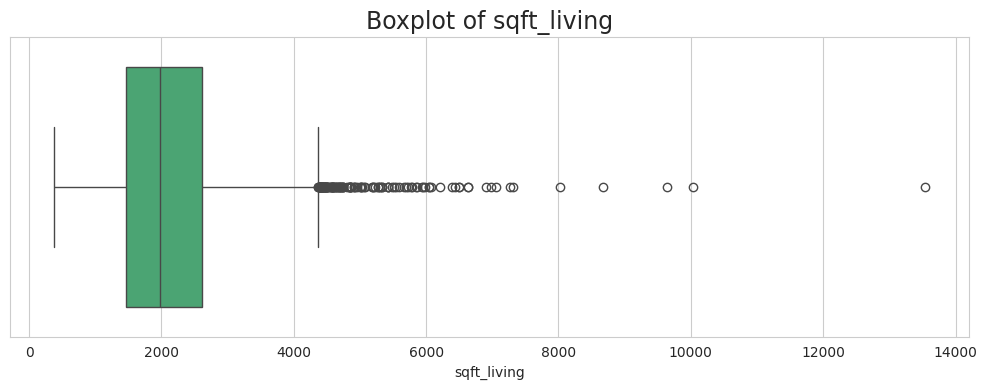

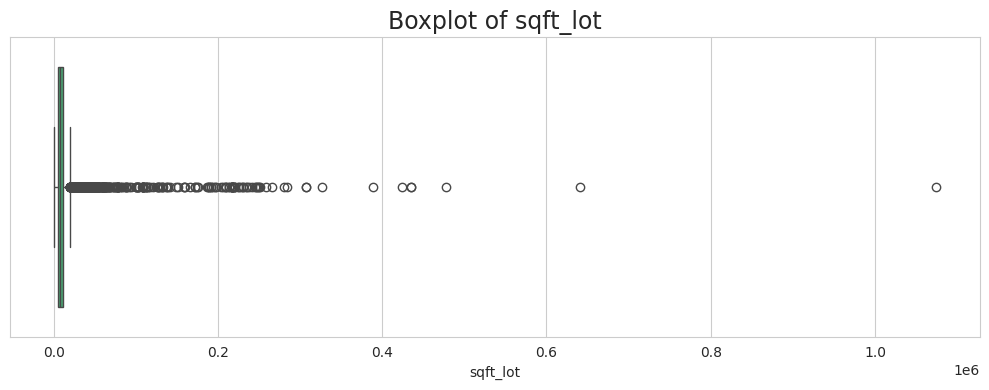

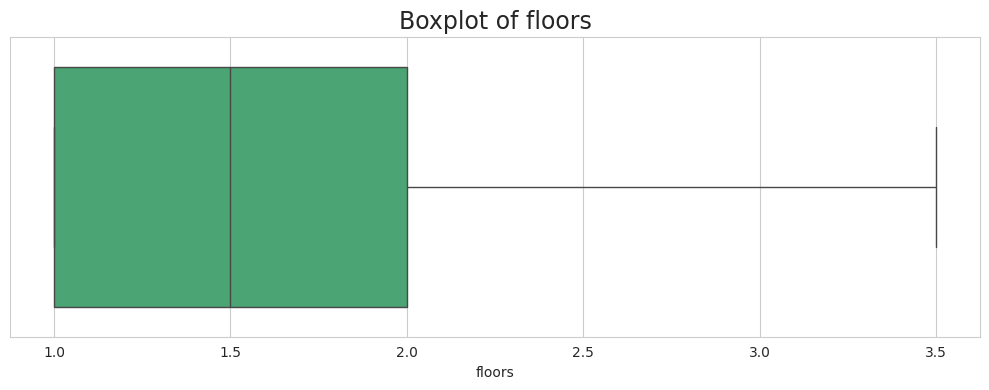

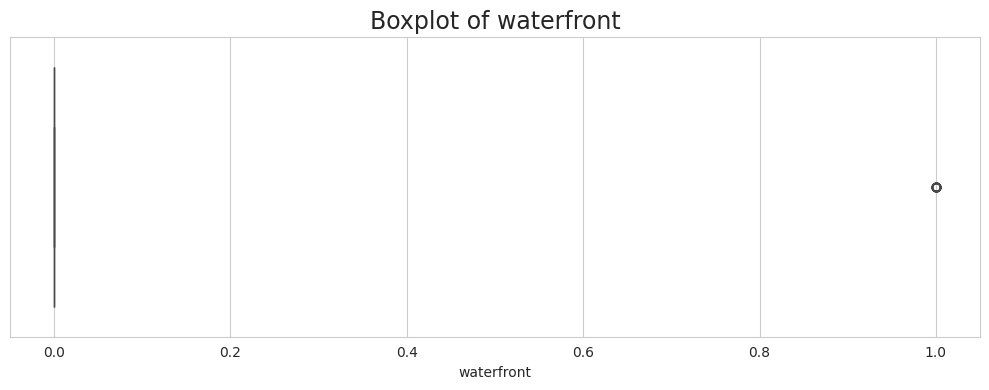

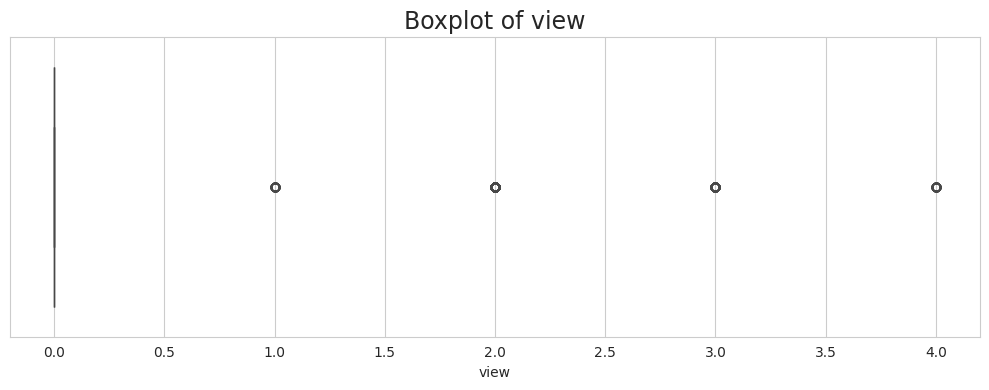

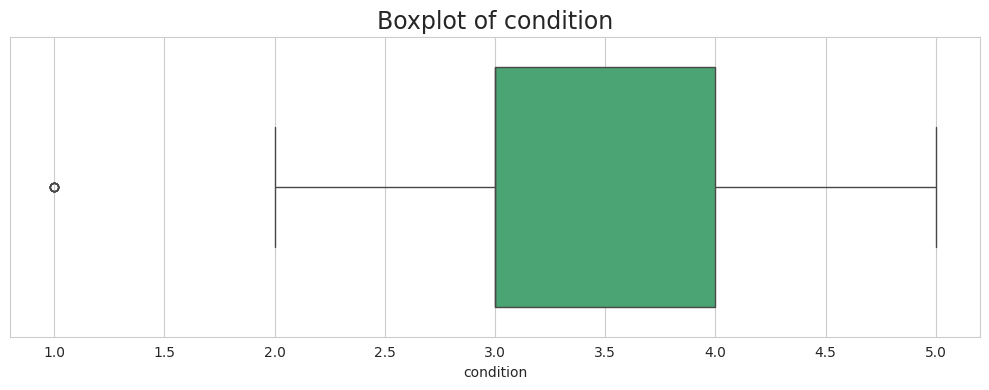

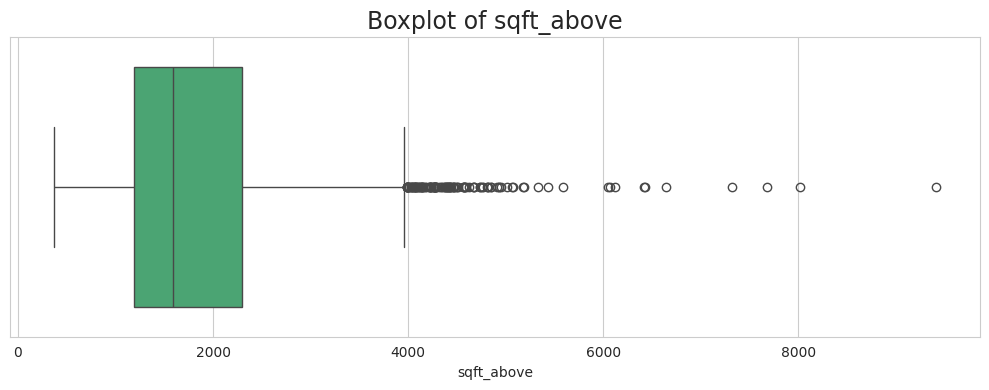

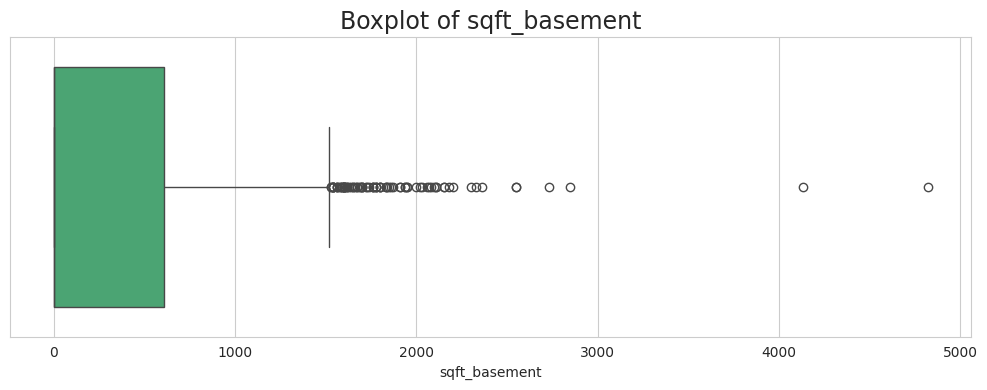

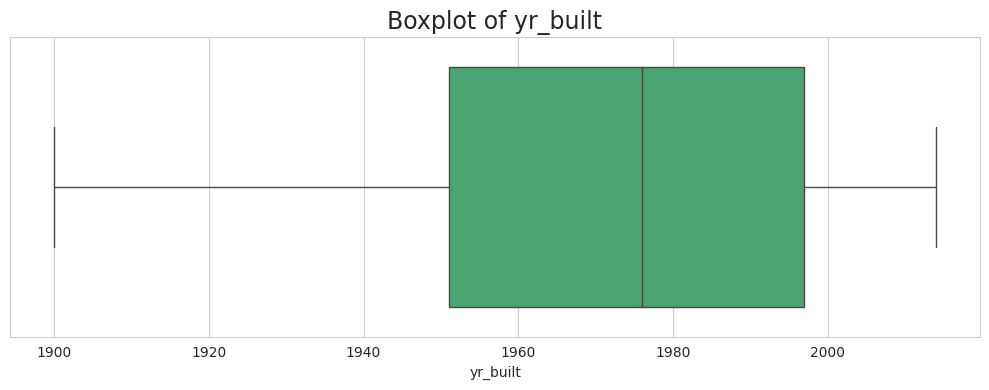

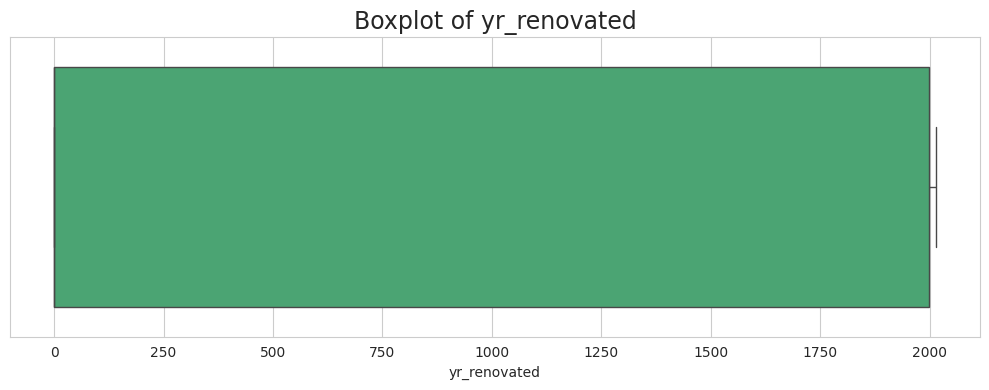

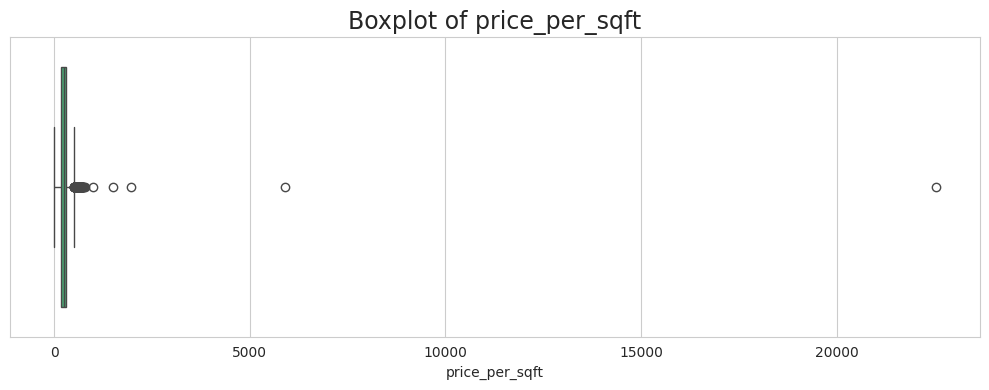


Correlation Matrix:
                   price  bedrooms  bathrooms  sqft_living  sqft_lot  \
price           1.000000  0.200336   0.327110     0.430410  0.050451   
bedrooms        0.200336  1.000000   0.545920     0.594884  0.068819   
bathrooms       0.327110  0.545920   1.000000     0.761154  0.107837   
sqft_living     0.430410  0.594884   0.761154     1.000000  0.210538   
sqft_lot        0.050451  0.068819   0.107837     0.210538  1.000000   
floors          0.151461  0.177895   0.486428     0.344850  0.003750   
waterfront      0.135648 -0.003483   0.076232     0.117616  0.017241   
view            0.228504  0.111028   0.211960     0.311009  0.073907   
condition       0.034915  0.025080  -0.119994    -0.062826  0.000558   
sqft_above      0.367570  0.484705   0.689918     0.876443  0.216455   
sqft_basement   0.210427  0.334165   0.298020     0.447206  0.034842   
yr_built        0.021857  0.142461   0.463498     0.287775  0.050706   
yr_renovated   -0.028774 -0.061082  -0.2158

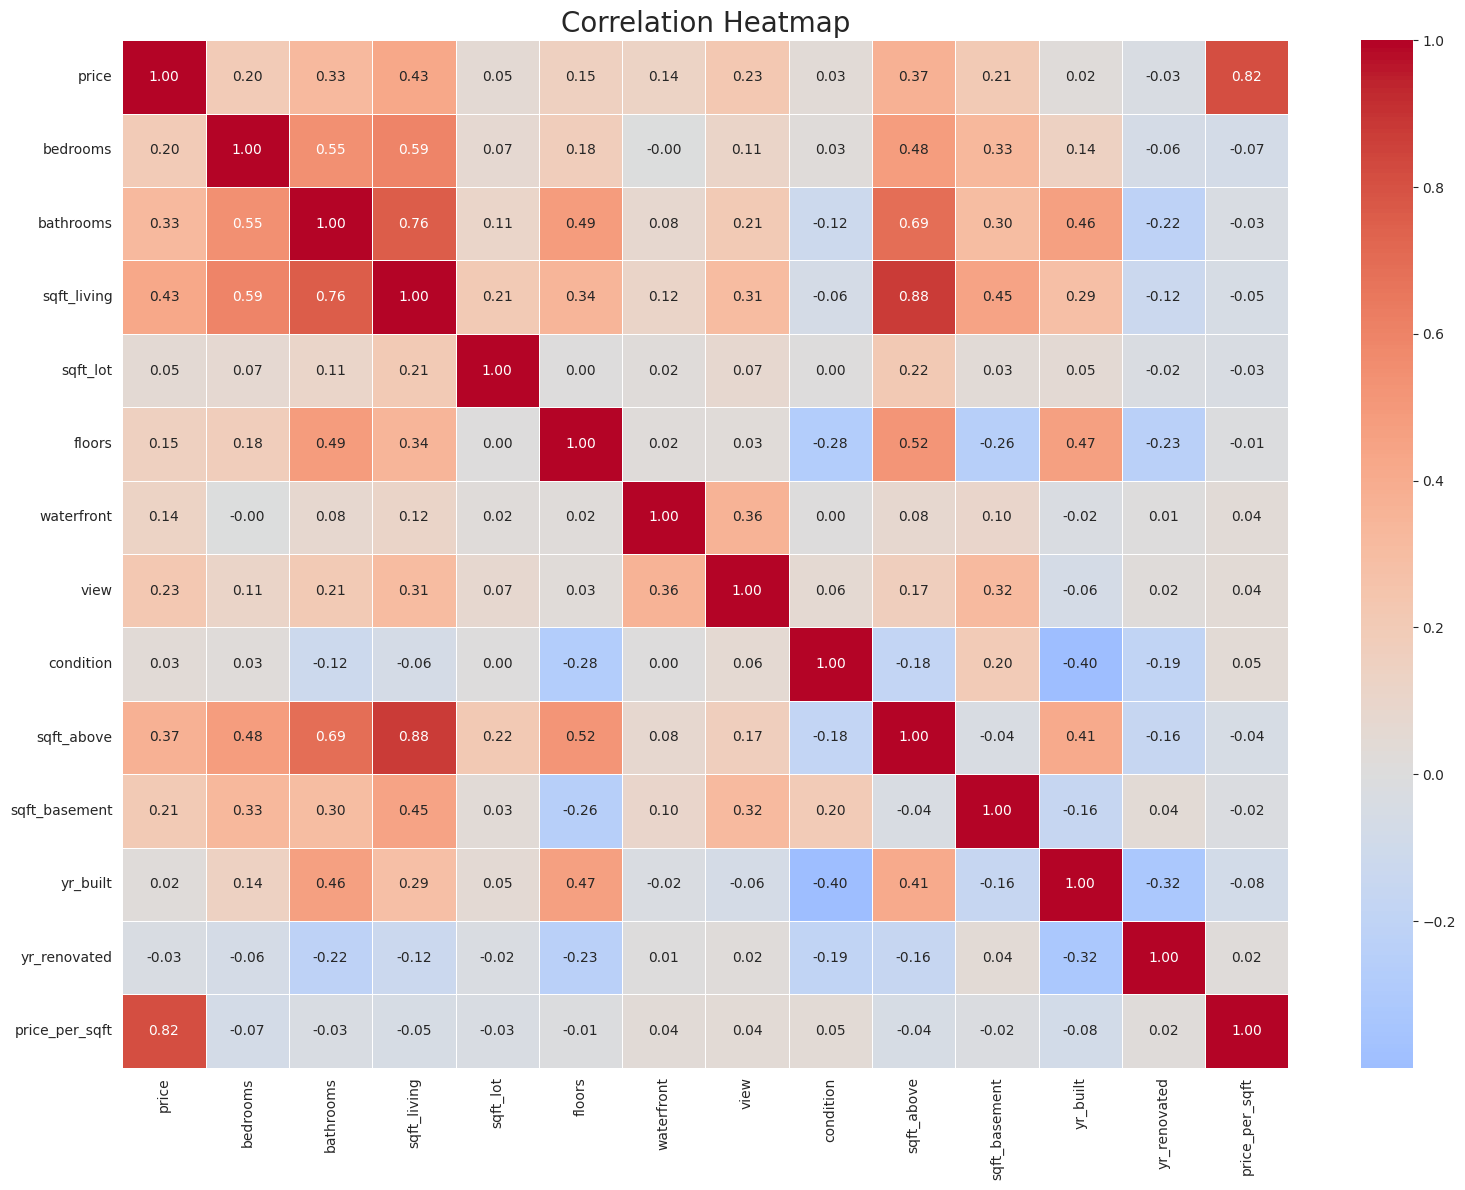

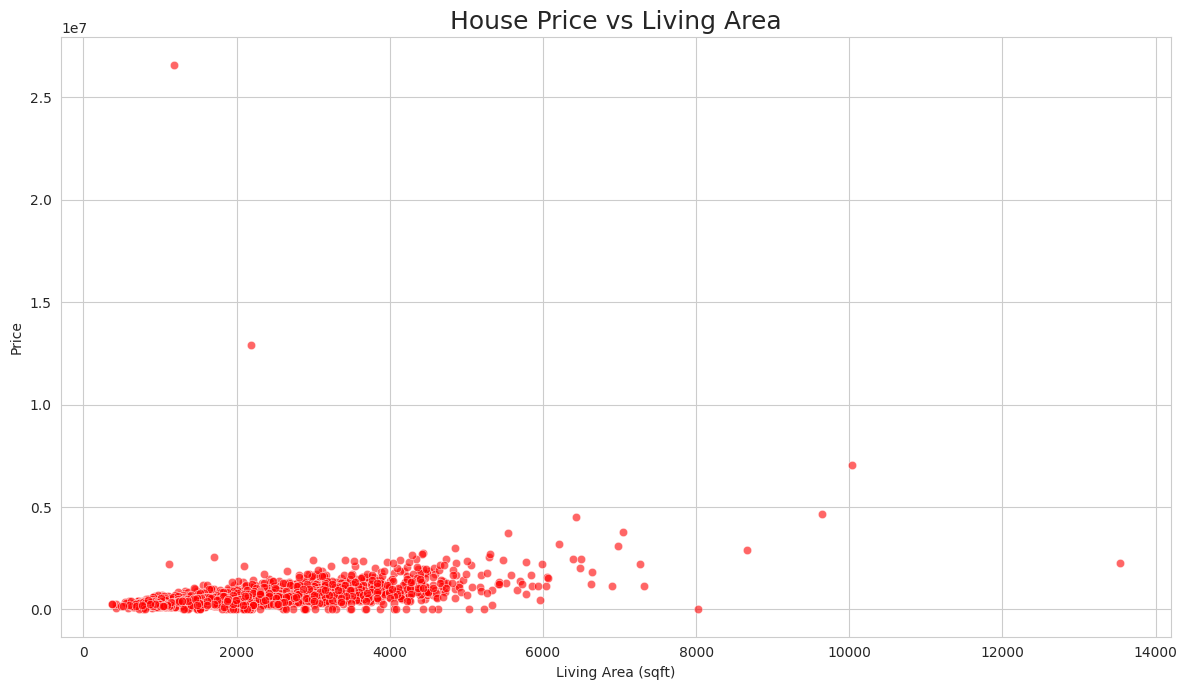

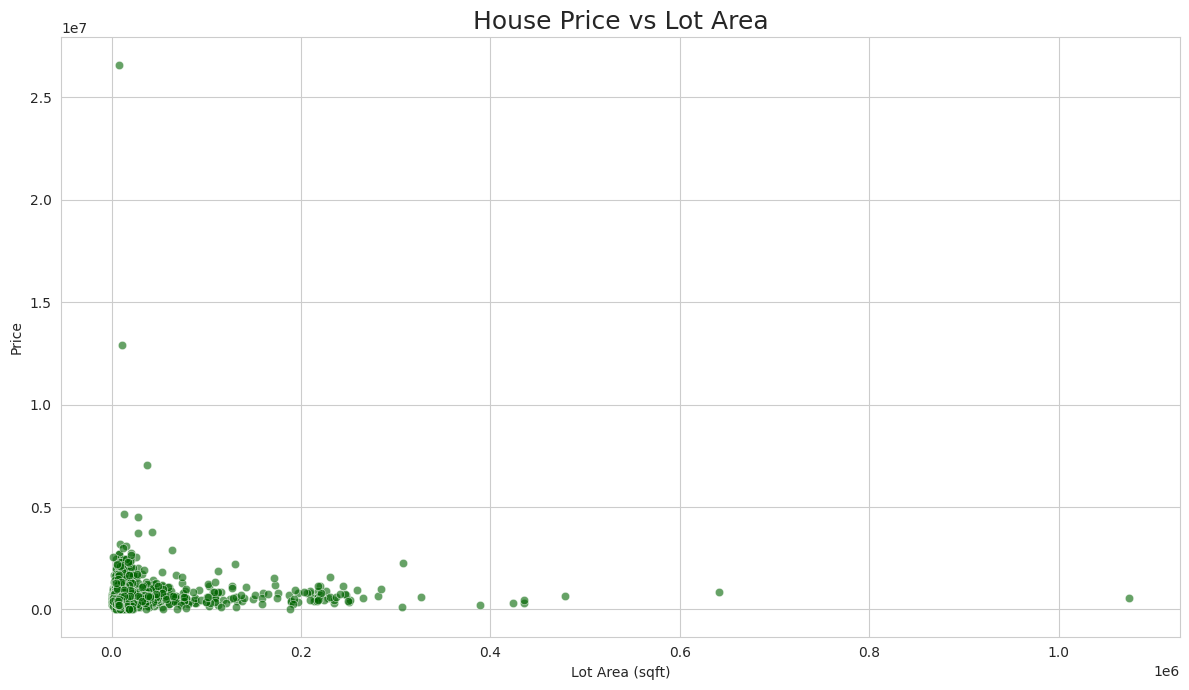

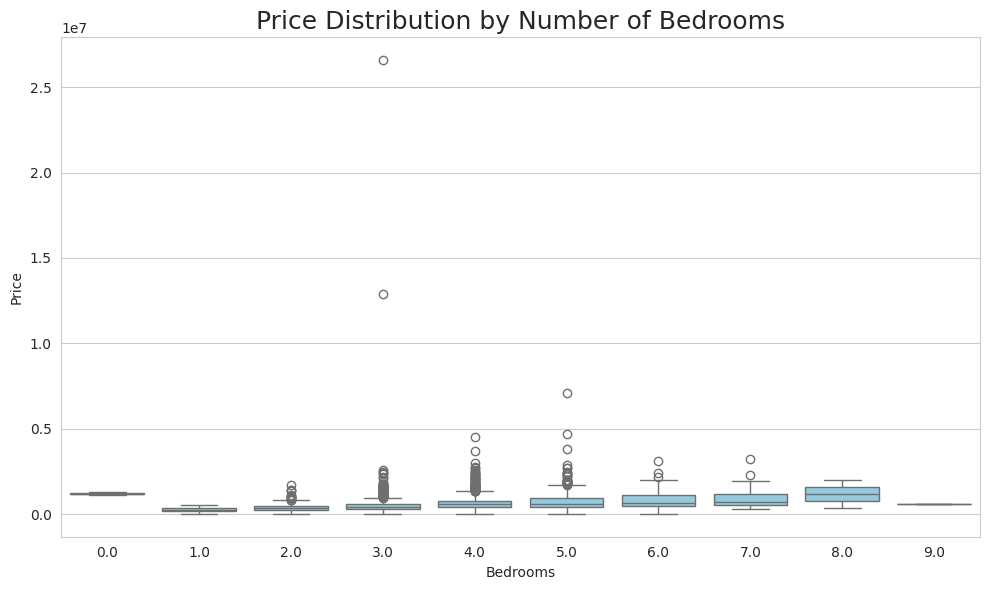

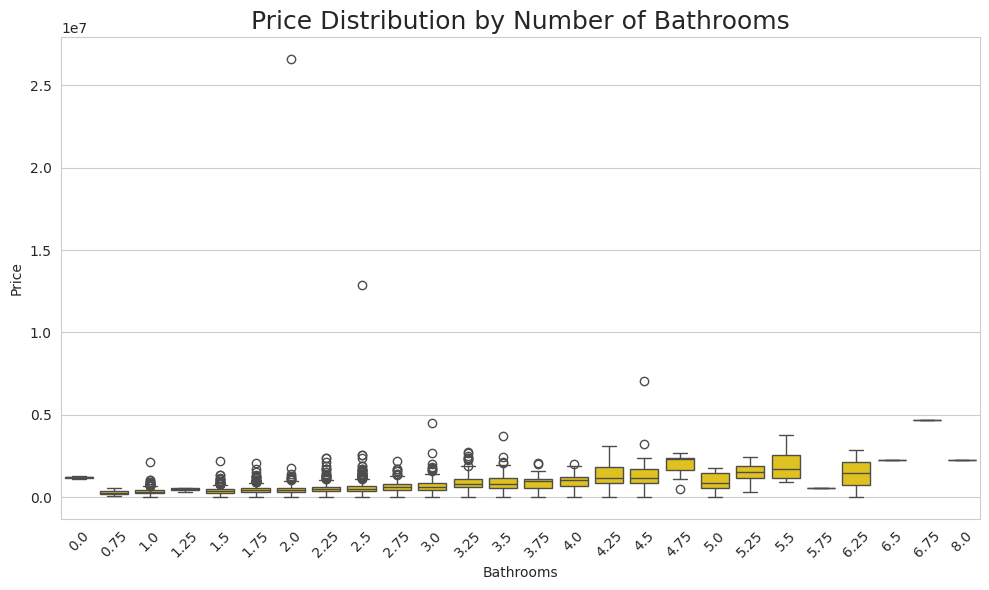

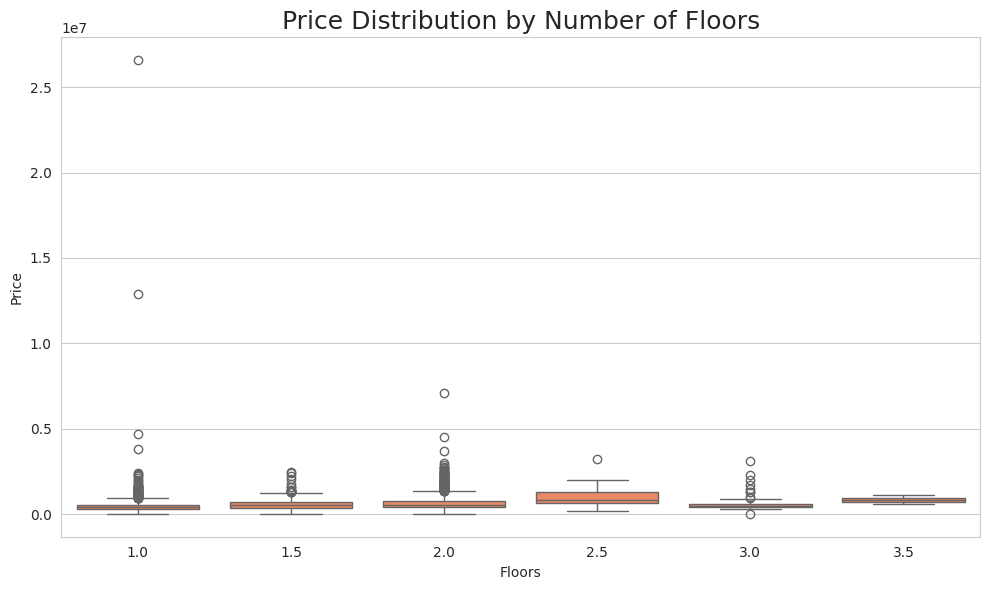

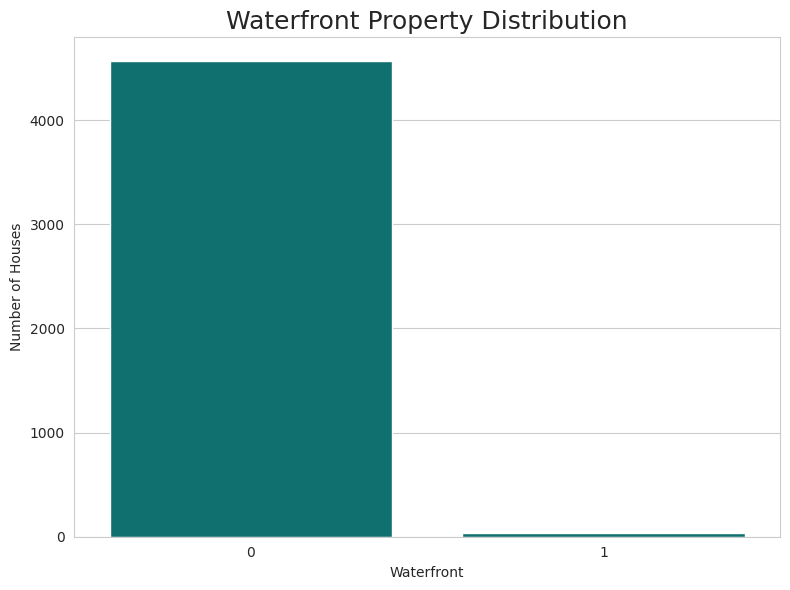

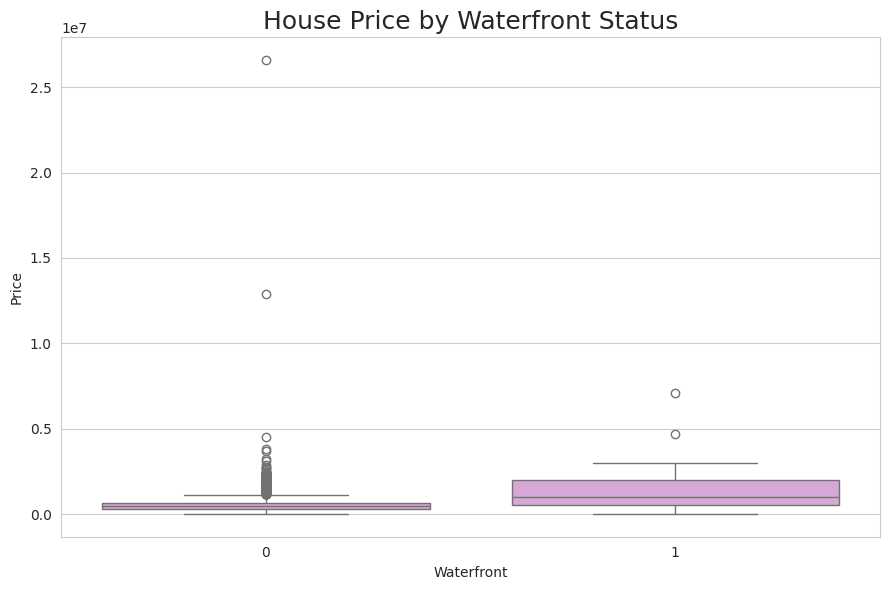

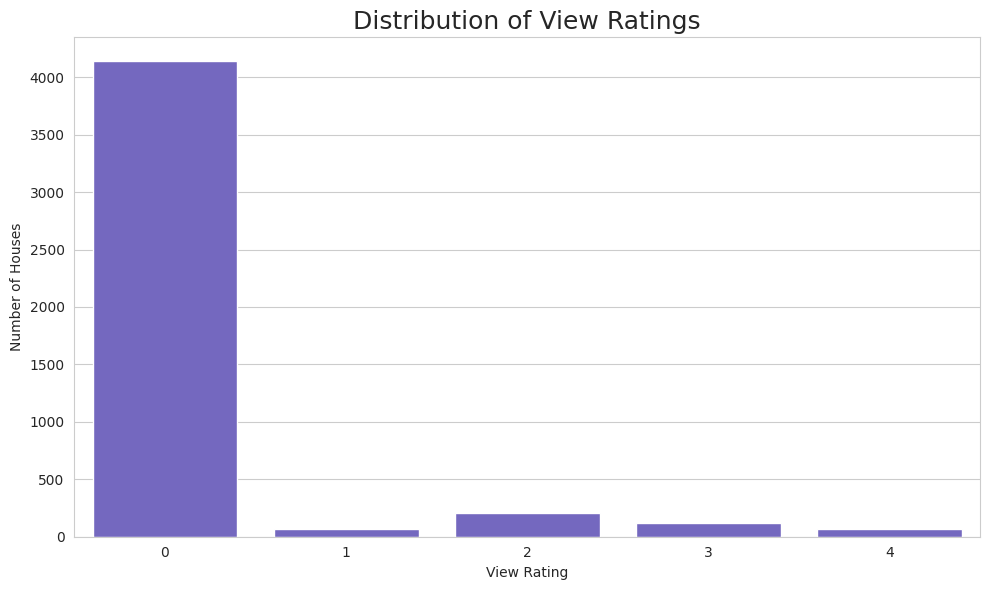

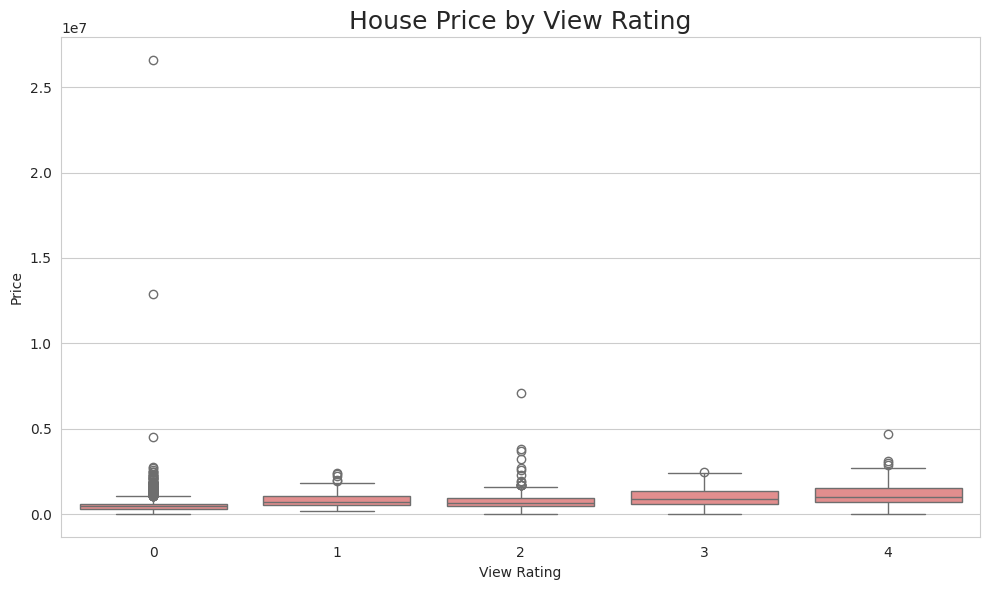

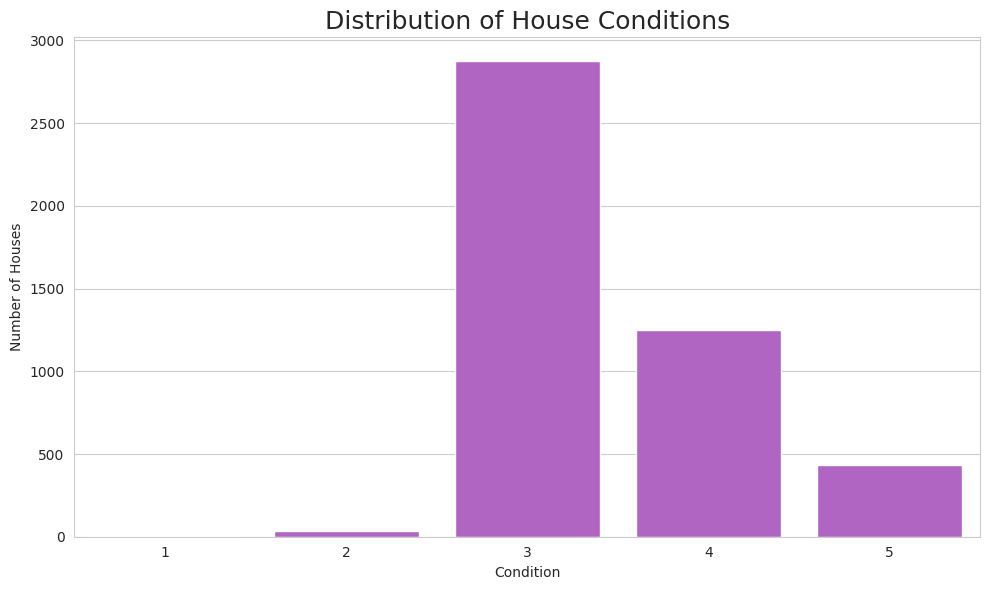

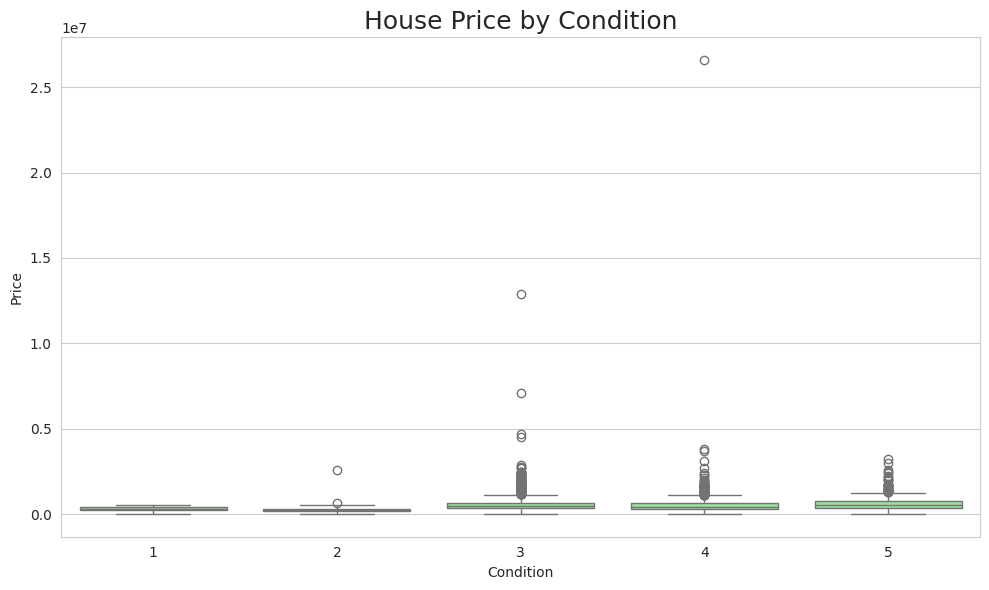

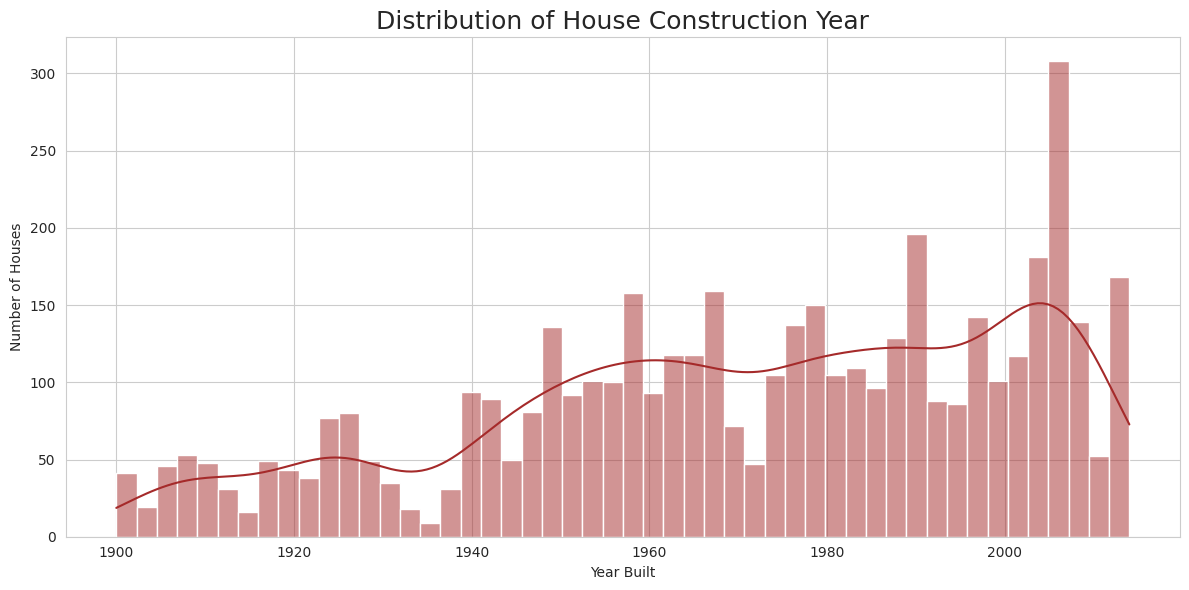

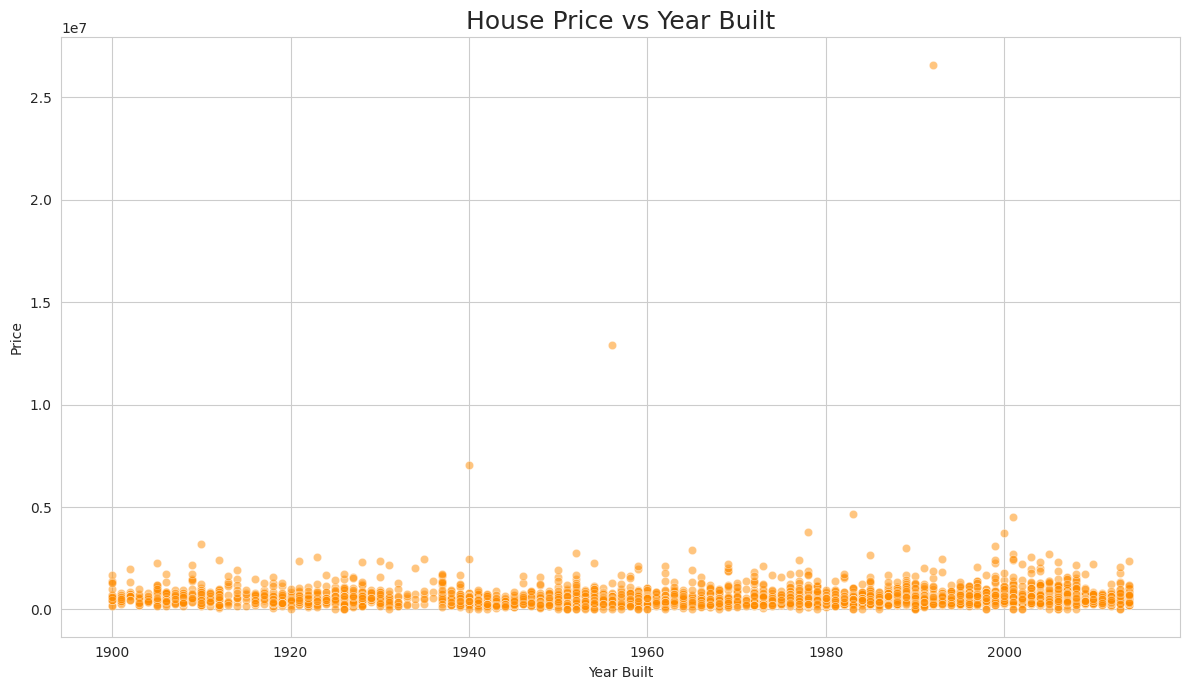

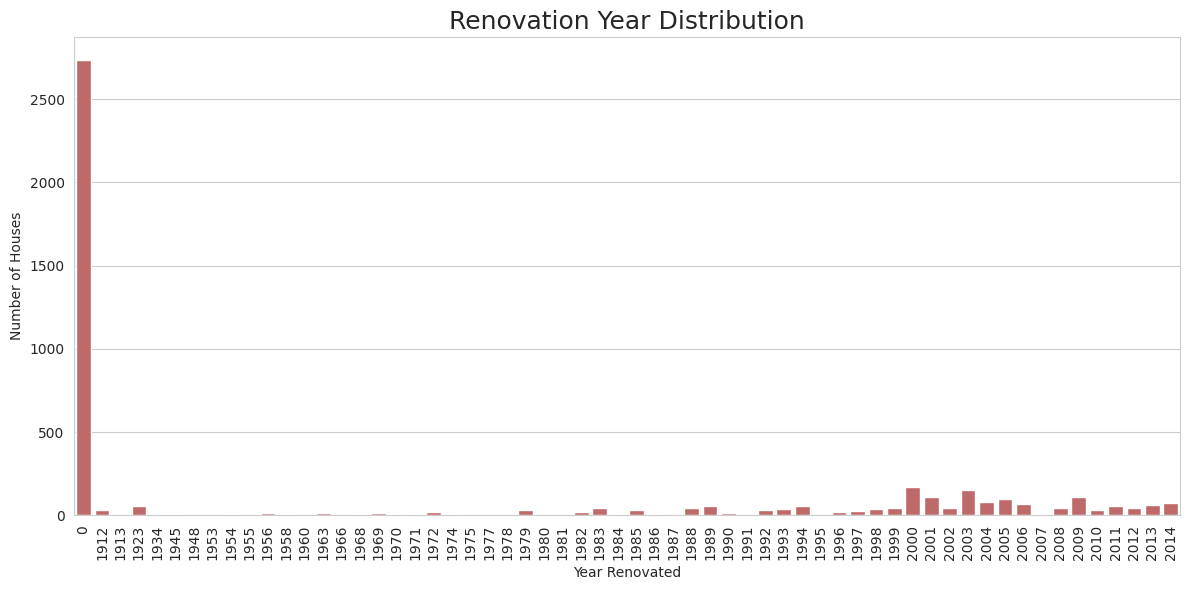

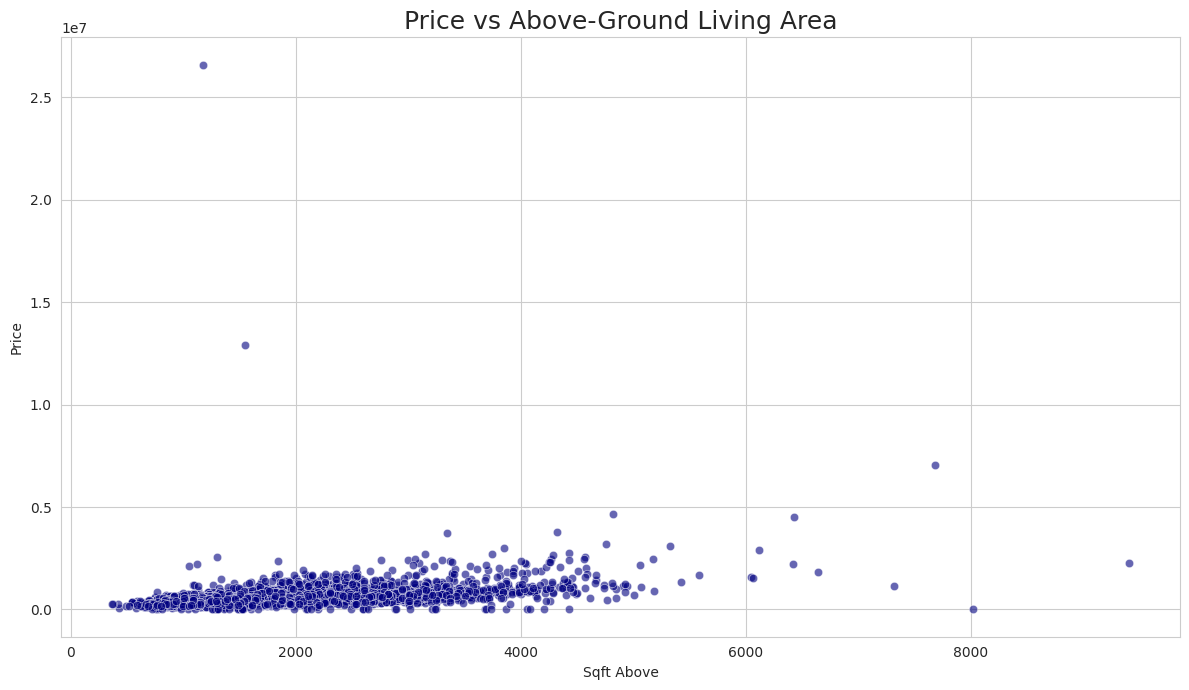

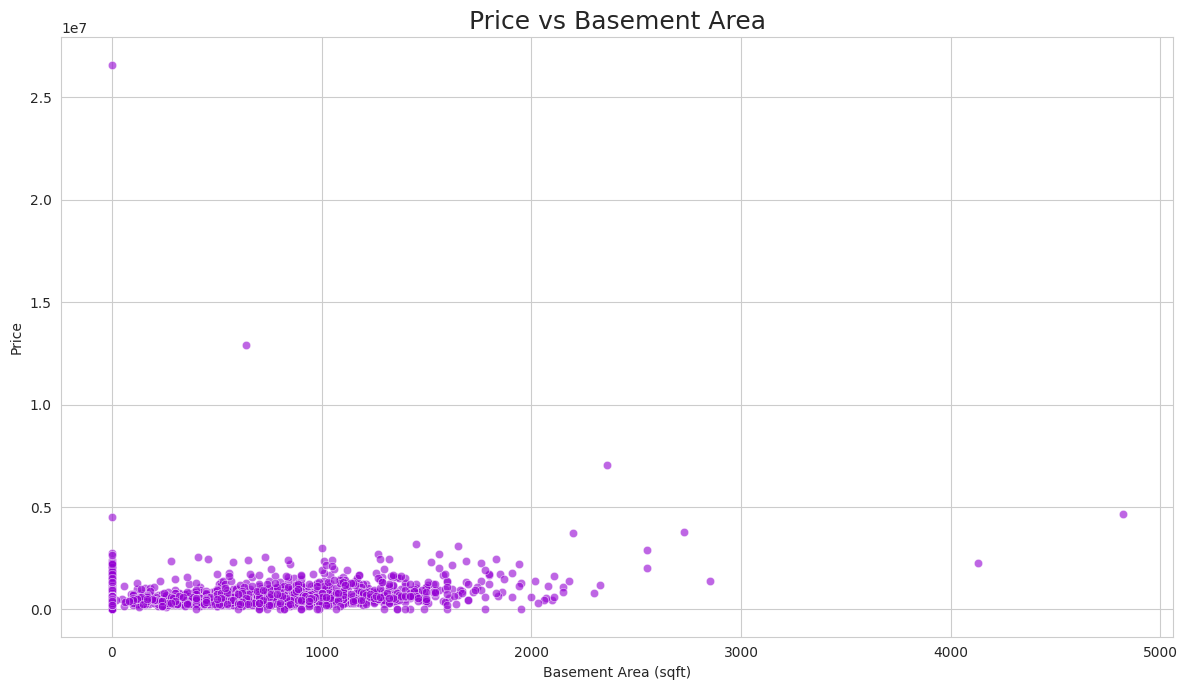

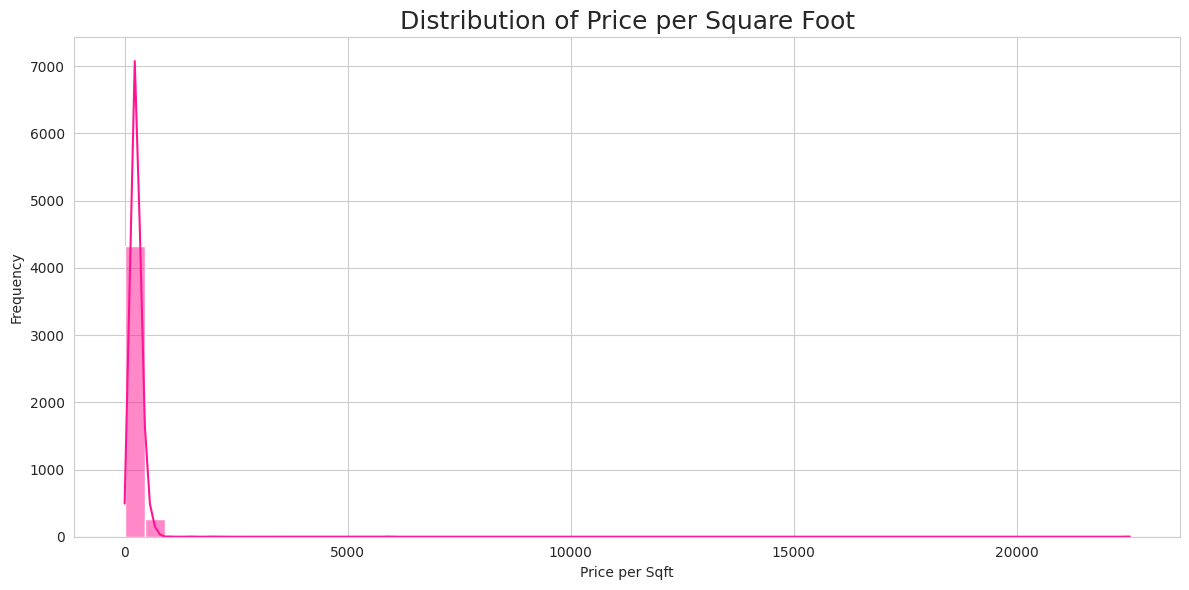

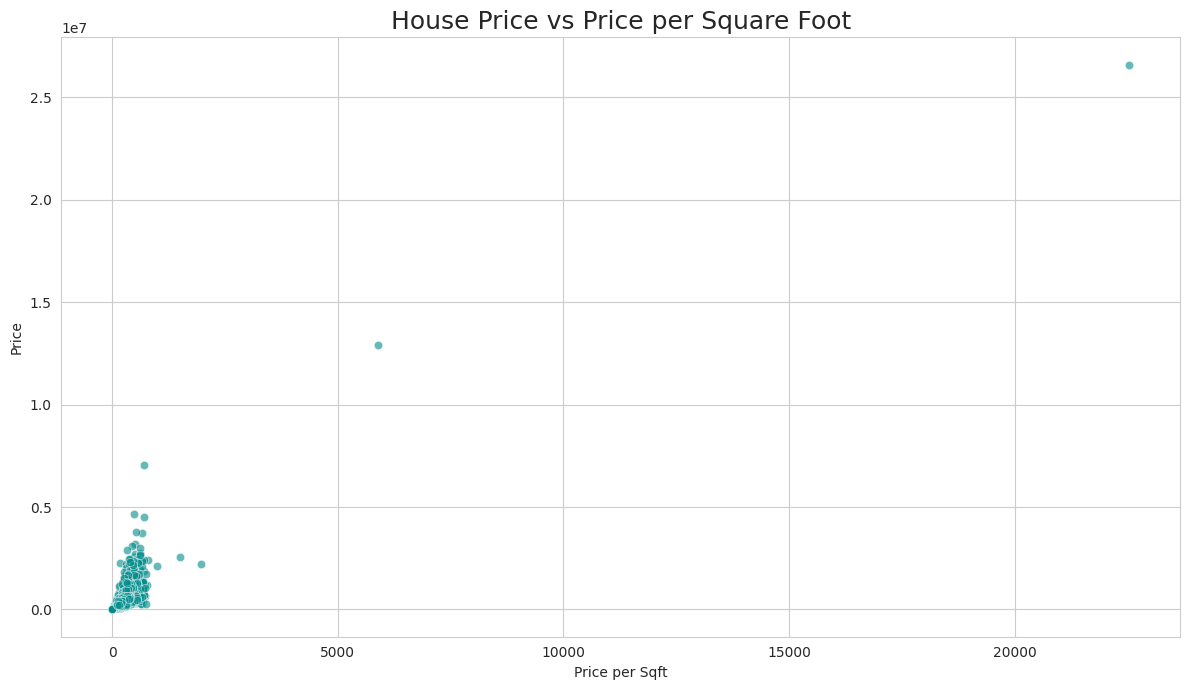

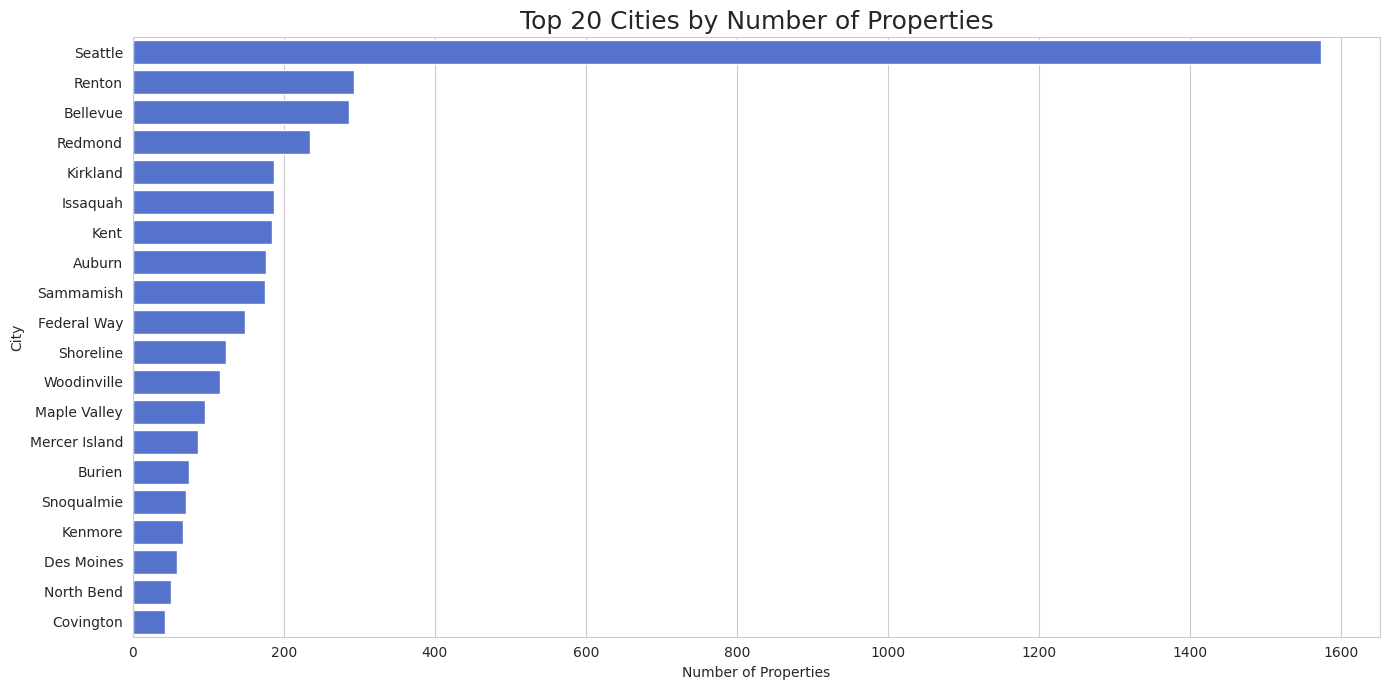

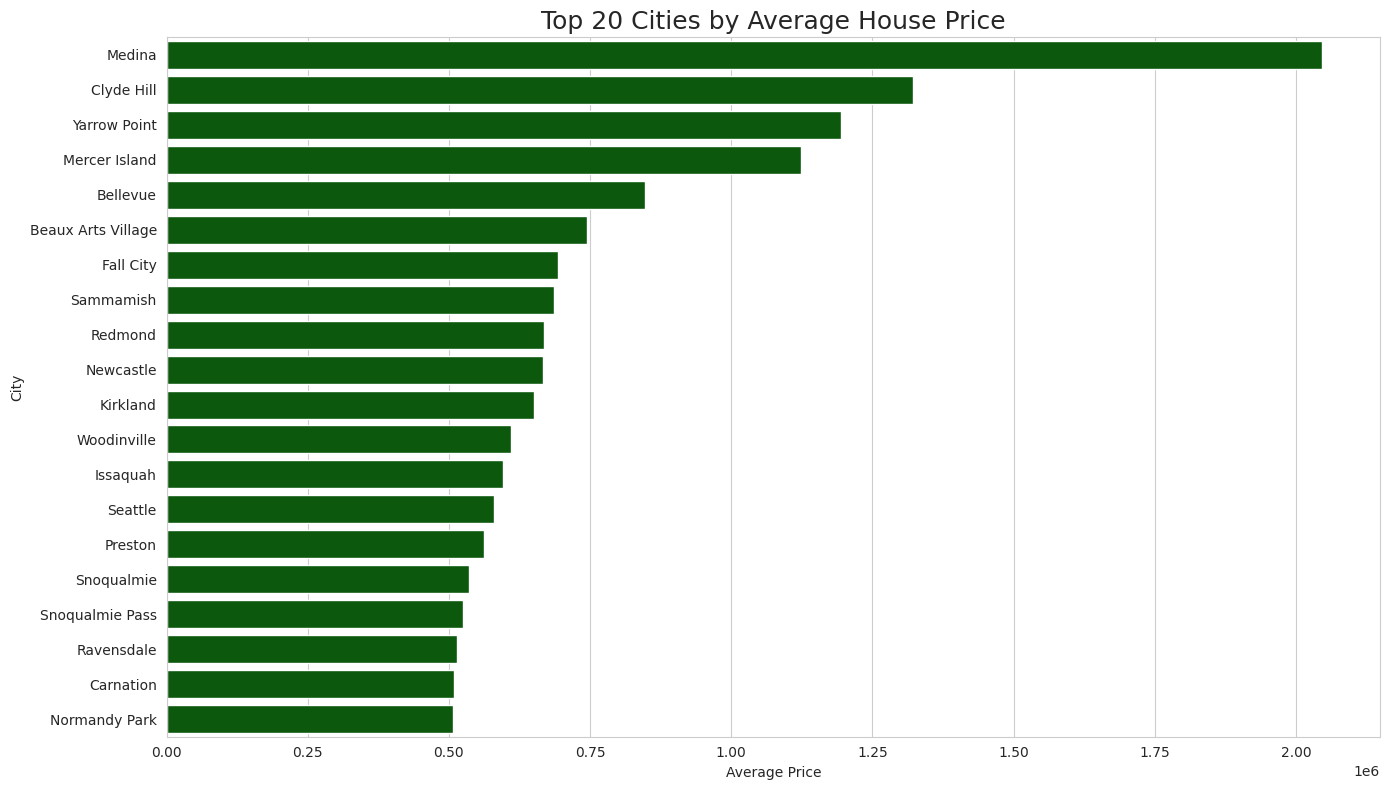

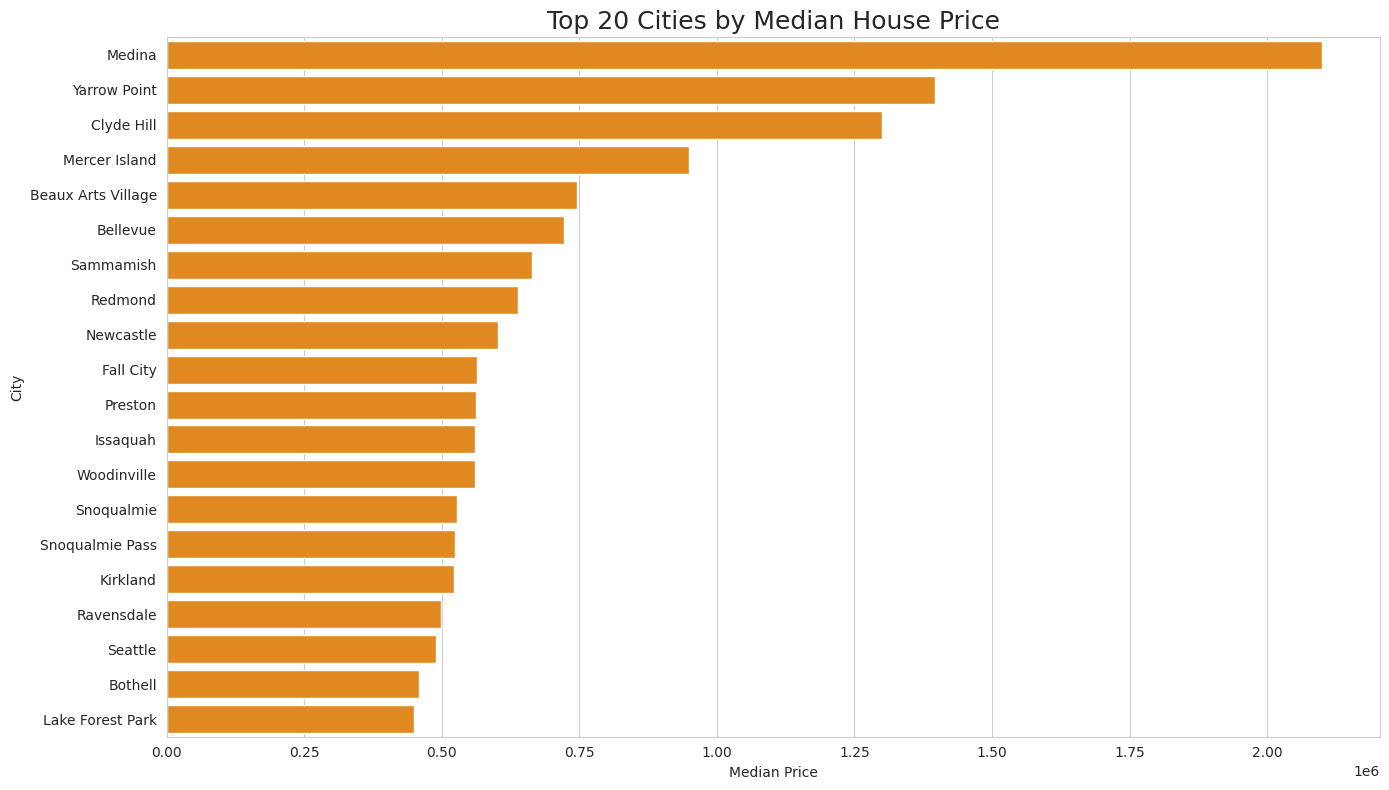

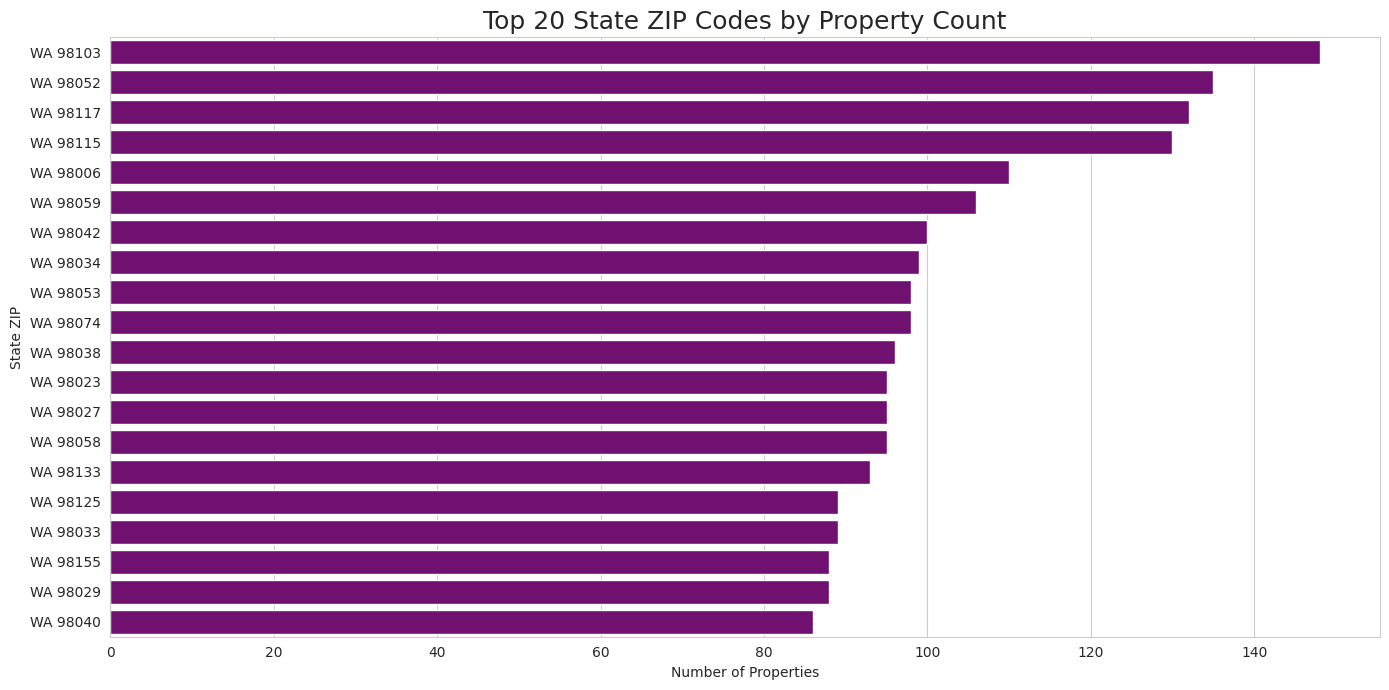

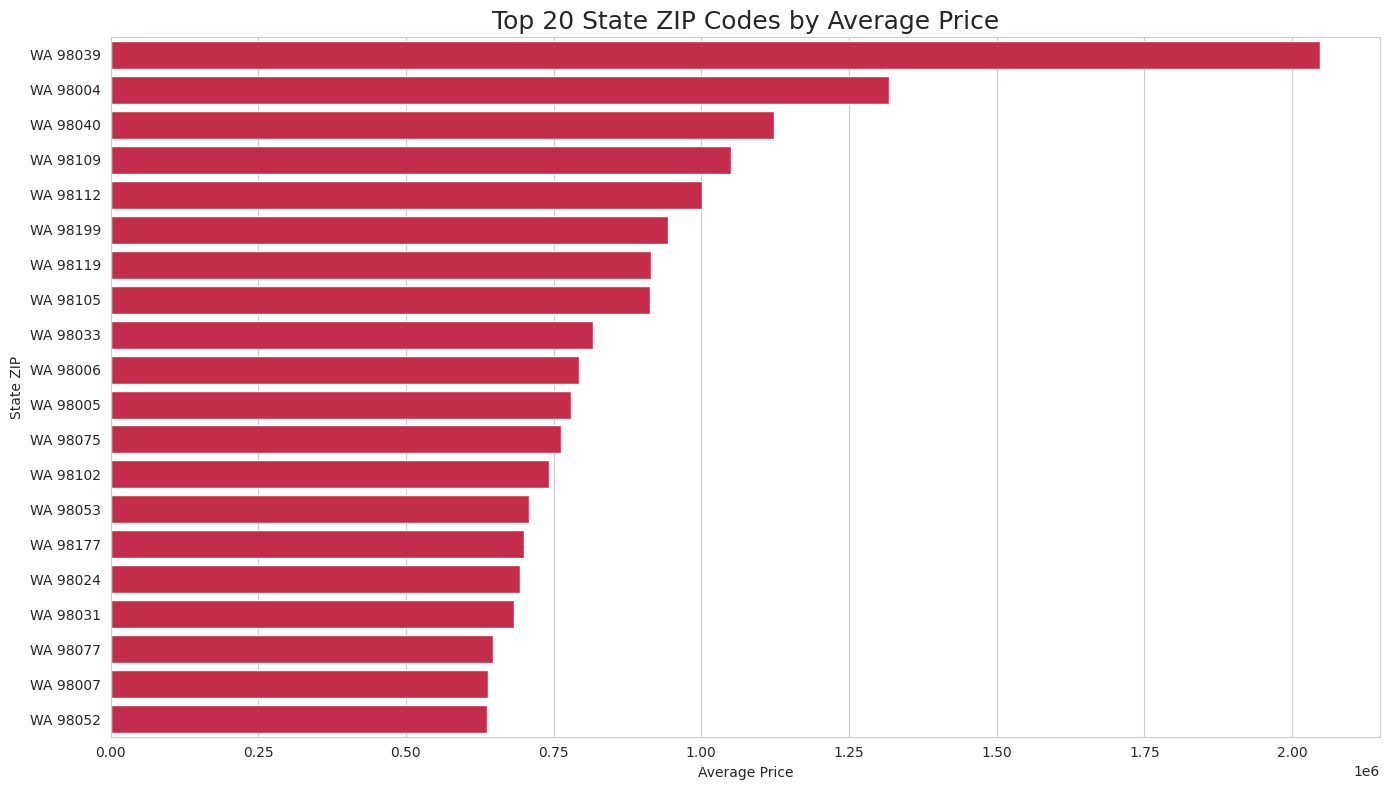

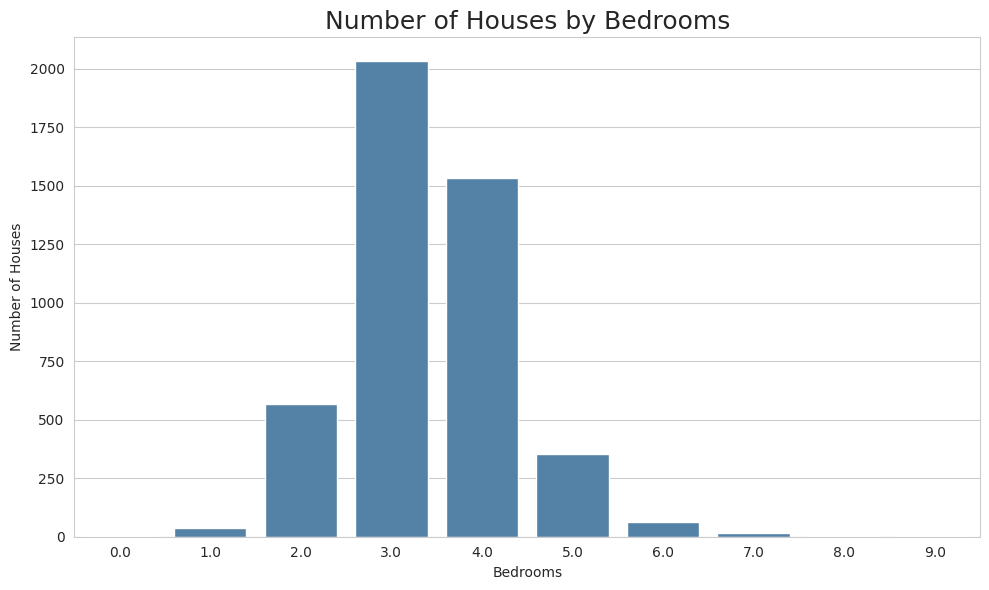

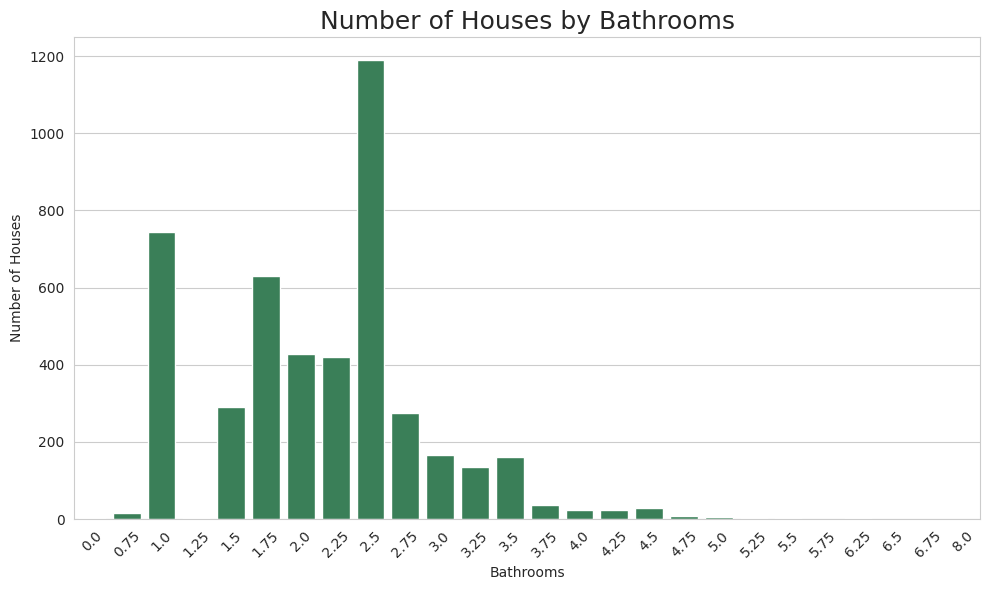

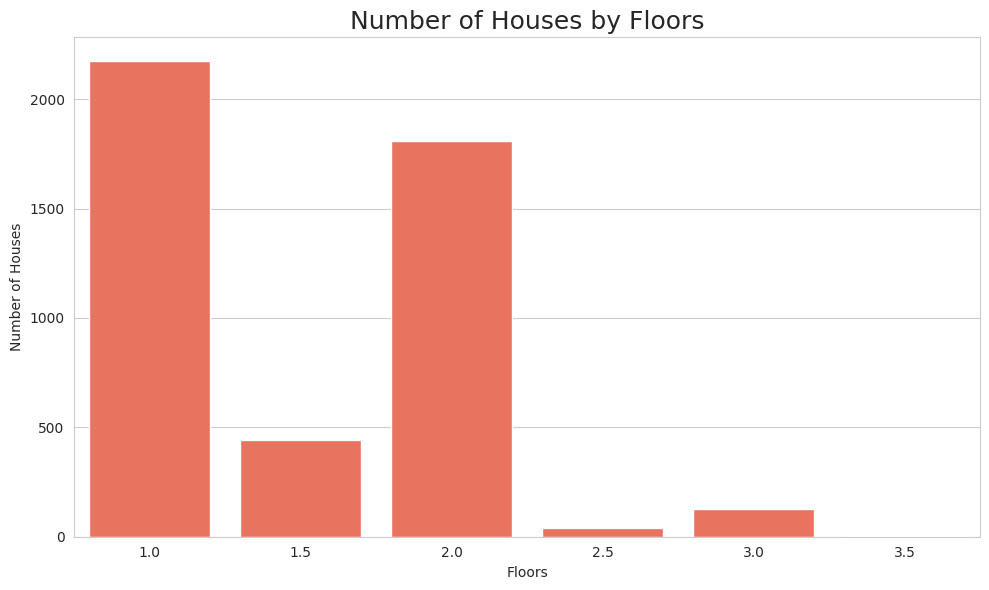

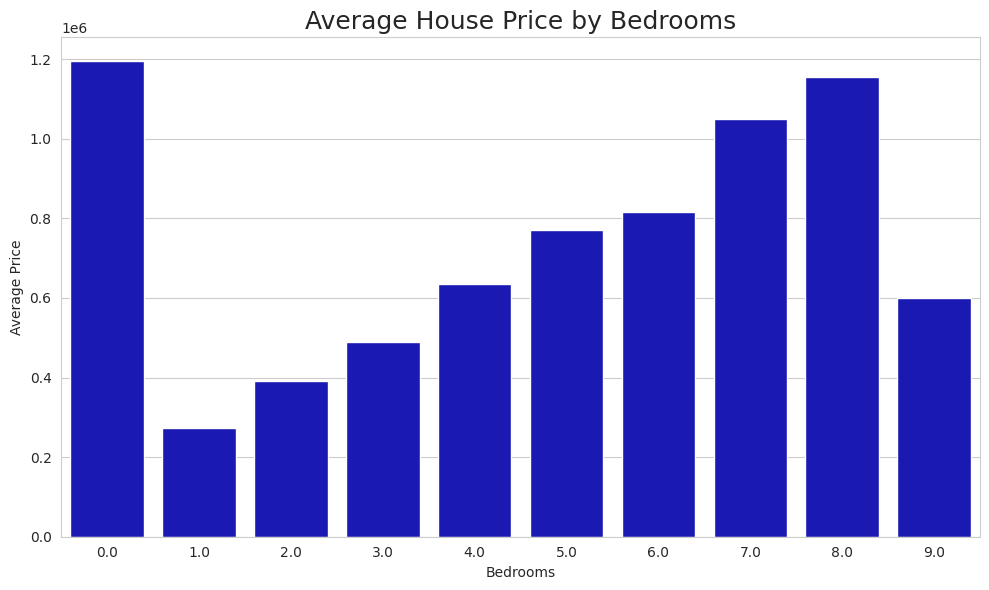

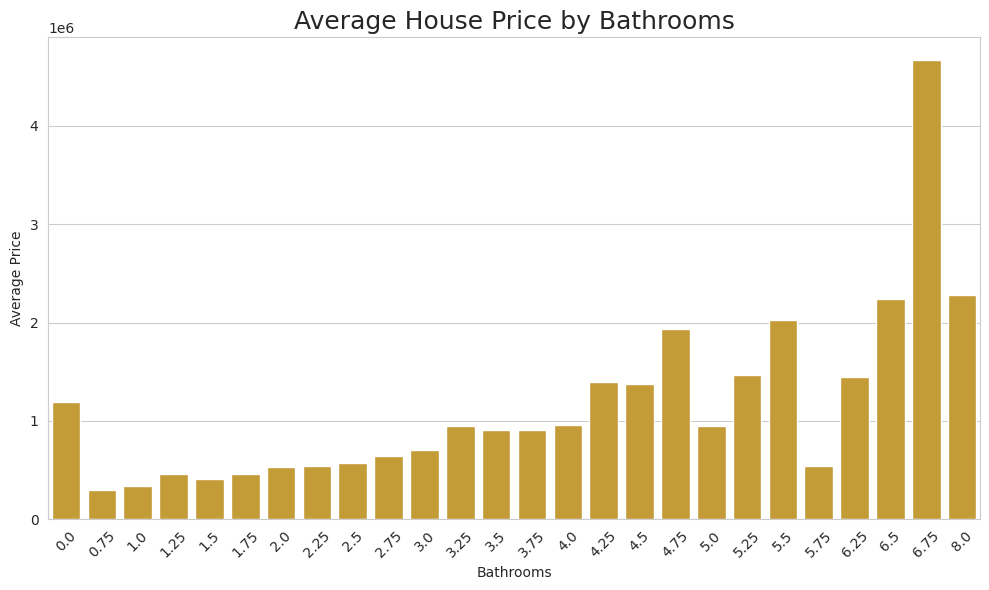

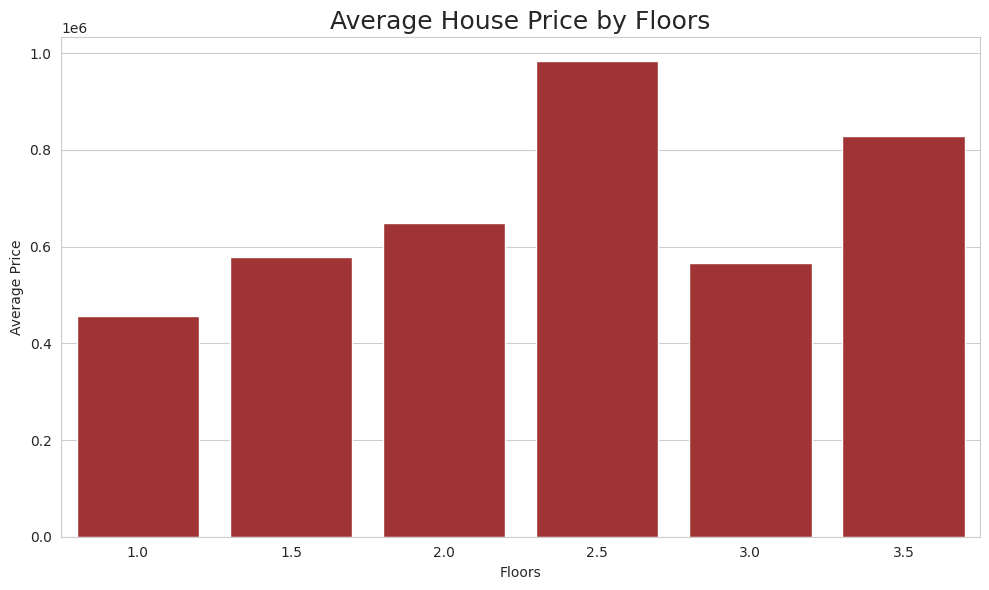

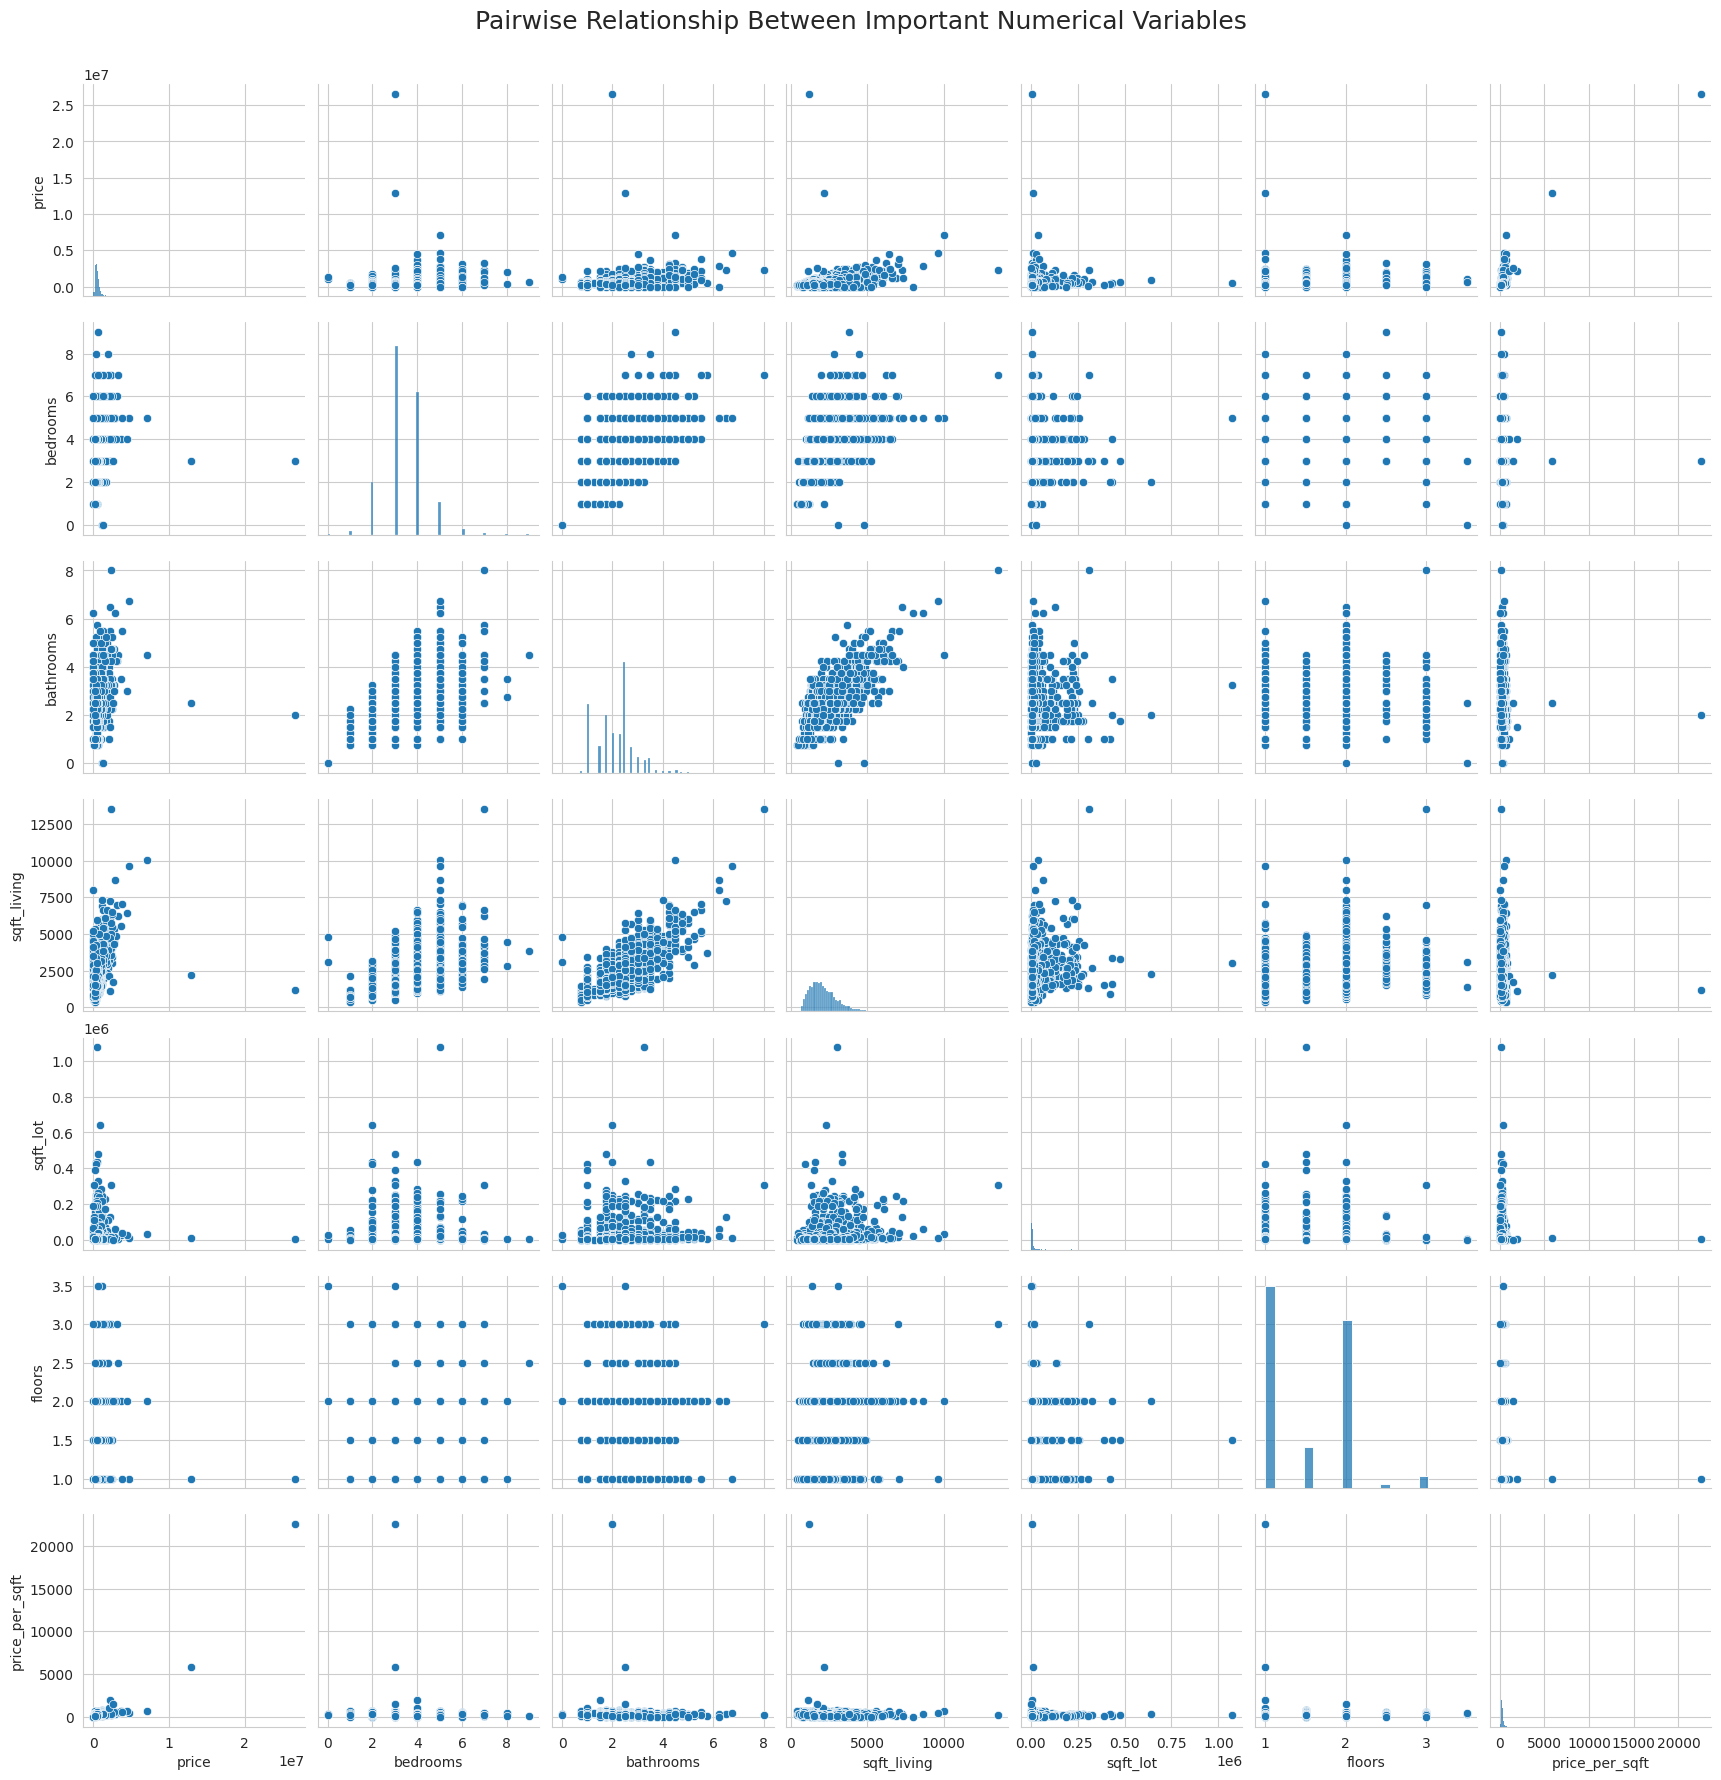


CORRELATION WITH PRICE
price             1.000000
price_per_sqft    0.819279
sqft_living       0.430410
sqft_above        0.367570
bathrooms         0.327110
view              0.228504
sqft_basement     0.210427
bedrooms          0.200336
floors            0.151461
waterfront        0.135648
sqft_lot          0.050451
condition         0.034915
yr_built          0.021857
yr_renovated     -0.028774
Name: price, dtype: float64

TOP 10 MOST EXPENSIVE HOUSES
           date       price  bedrooms  bathrooms  sqft_living           city  \
4350 2014-07-03  26590000.0       3.0       2.00         1180           Kent   
4346 2014-06-23  12899000.0       3.0       2.50         2190        Seattle   
2286 2014-06-11   7062500.0       5.0       4.50        10040       Bellevue   
2654 2014-06-17   4668000.0       5.0       6.75         9640  Mercer Island   
2761 2014-06-18   4489000.0       4.0       3.00         6430       Bellevue   
3729 2014-07-01   3800000.0       5.0       5.50         705

In [13]:
# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plot style
sns.set_style("whitegrid")


print("=" * 70)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 70)

print("\nFirst 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

# ============================================================
# 3. BASIC INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("STATISTICAL SUMMARY")
print("=" * 70)

print(df.describe(include="all").T)

# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

missing = df.isnull().sum()

print(missing)

# Missing-value percentage
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percent
})

print("\nMissing Value Summary:")
print(missing_table)

# Visualization of missing values
plt.figure(figsize=(14, 6))

missing_plot = missing[missing > 0].sort_values(ascending=False)

if len(missing_plot) > 0:
    sns.barplot(
        x=missing_plot.index,
        y=missing_plot.values,
        color="crimson"
    )

    plt.title("Missing Values by Column", fontsize=18)
    plt.xlabel("Columns")
    plt.ylabel("Number of Missing Values")
    plt.xticks(rotation=60)
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

# ============================================================
# 5. CHECK DUPLICATES
# ============================================================

print("\n" + "=" * 70)
print("DUPLICATE VALUES")
print("=" * 70)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

# ============================================================
# 6. DATA TYPES
# ============================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

# ============================================================
# 7. CONVERT DATE COLUMN
# ============================================================

df["date"] = pd.to_datetime(df["date"], errors="coerce")

print("\nDate column converted to datetime.")

# ============================================================
# 8. NUMERICAL COLUMNS
# ============================================================

numeric_columns = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "waterfront",
    "view",
    "condition",
    "sqft_above",
    "sqft_basement",
    "yr_built",
    "yr_renovated",
    "price_per_sqft"
]

print("\nNumerical Columns:")
print(numeric_columns)

# ============================================================
# 9. CATEGORICAL COLUMNS
# ============================================================

categorical_columns = [
    "street",
    "city",
    "statezip"
]

print("\nCategorical Columns:")
print(categorical_columns)

# ============================================================
# 10. PRICE DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["price"].dropna(),
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of House Prices", fontsize=18)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 11. PRICE BOXPLOT
# ============================================================

plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["price"],
    color="orange"
)

plt.title("Boxplot of House Prices", fontsize=18)
plt.xlabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 12. ALL NUMERICAL DISTRIBUTIONS
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        df[col].dropna(),
        bins=40,
        kde=True,
        color="purple"
    )

    plt.title(f"Distribution of {col}", fontsize=17)
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# ============================================================
# 13. ALL NUMERICAL BOXPLOTS
# ============================================================

for col in numeric_columns:

    plt.figure(figsize=(10, 4))

    sns.boxplot(
        x=df[col],
        color="mediumseagreen"
    )

    plt.title(f"Boxplot of {col}", fontsize=17)
    plt.xlabel(col)

    plt.tight_layout()
    plt.show()

# ============================================================
# 14. CORRELATION MATRIX
# ============================================================

correlation = df[numeric_columns].corr()

print("\nCorrelation Matrix:")
print(correlation)

# ============================================================
# 15. CORRELATION HEATMAP
# ============================================================

plt.figure(figsize=(16, 12))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    center=0
)

plt.title("Correlation Heatmap", fontsize=20)
plt.tight_layout()
plt.show()

# ============================================================
# 16. PRICE VS SQFT LIVING
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="sqft_living",
    y="price",
    color="red",
    alpha=0.6
)

plt.title("House Price vs Living Area", fontsize=18)
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 17. PRICE VS SQFT LOT
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="sqft_lot",
    y="price",
    color="darkgreen",
    alpha=0.6
)

plt.title("House Price vs Lot Area", fontsize=18)
plt.xlabel("Lot Area (sqft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 18. PRICE VS BEDROOMS
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bedrooms",
    y="price",
    color="skyblue"
)

plt.title("Price Distribution by Number of Bedrooms", fontsize=18)
plt.xlabel("Bedrooms")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 19. PRICE VS BATHROOMS
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="bathrooms",
    y="price",
    color="gold"
)

plt.title("Price Distribution by Number of Bathrooms", fontsize=18)
plt.xlabel("Bathrooms")
plt.ylabel("Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 20. PRICE VS FLOORS
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="floors",
    y="price",
    color="coral"
)

plt.title("Price Distribution by Number of Floors", fontsize=18)
plt.xlabel("Floors")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 21. WATERFRONT ANALYSIS
# ============================================================

plt.figure(figsize=(8, 6))

sns.countplot(
    data=df,
    x="waterfront",
    color="teal"
)

plt.title("Waterfront Property Distribution", fontsize=18)
plt.xlabel("Waterfront")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 22. WATERFRONT VS PRICE
# ============================================================

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="waterfront",
    y="price",
    color="plum"
)

plt.title("House Price by Waterfront Status", fontsize=18)
plt.xlabel("Waterfront")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 23. VIEW DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="view",
    color="slateblue"
)

plt.title("Distribution of View Ratings", fontsize=18)
plt.xlabel("View Rating")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 24. VIEW VS PRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="view",
    y="price",
    color="lightcoral"
)

plt.title("House Price by View Rating", fontsize=18)
plt.xlabel("View Rating")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 25. CONDITION DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="condition",
    color="mediumorchid"
)

plt.title("Distribution of House Conditions", fontsize=18)
plt.xlabel("Condition")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 26. CONDITION VS PRICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="condition",
    y="price",
    color="lightgreen"
)

plt.title("House Price by Condition", fontsize=18)
plt.xlabel("Condition")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 27. YEAR BUILT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="yr_built",
    bins=50,
    kde=True,
    color="brown"
)

plt.title("Distribution of House Construction Year", fontsize=18)
plt.xlabel("Year Built")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 28. YEAR BUILT VS PRICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="yr_built",
    y="price",
    color="darkorange",
    alpha=0.5
)

plt.title("House Price vs Year Built", fontsize=18)
plt.xlabel("Year Built")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 29. RENOVATION ANALYSIS
# ============================================================

renovation_counts = df["yr_renovated"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

sns.barplot(
    x=renovation_counts.index,
    y=renovation_counts.values,
    color="indianred"
)

plt.title("Renovation Year Distribution", fontsize=18)
plt.xlabel("Year Renovated")
plt.ylabel("Number of Houses")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# ============================================================
# 30. SQFT ABOVE VS PRICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="sqft_above",
    y="price",
    color="navy",
    alpha=0.6
)

plt.title("Price vs Above-Ground Living Area", fontsize=18)
plt.xlabel("Sqft Above")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 31. SQFT BASEMENT VS PRICE
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="sqft_basement",
    y="price",
    color="darkviolet",
    alpha=0.6
)

plt.title("Price vs Basement Area", fontsize=18)
plt.xlabel("Basement Area (sqft)")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 32. PRICE PER SQFT DISTRIBUTION
# ============================================================

plt.figure(figsize=(12, 6))

sns.histplot(
    df["price_per_sqft"].dropna(),
    bins=50,
    kde=True,
    color="deeppink"
)

plt.title("Distribution of Price per Square Foot", fontsize=18)
plt.xlabel("Price per Sqft")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 33. PRICE VS PRICE PER SQFT
# ============================================================

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=df,
    x="price_per_sqft",
    y="price",
    color="darkcyan",
    alpha=0.6
)

plt.title("House Price vs Price per Square Foot", fontsize=18)
plt.xlabel("Price per Sqft")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

# ============================================================
# 34. CITY DISTRIBUTION - TOP 20
# ============================================================

top_cities = df["city"].value_counts().head(20)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=top_cities.values,
    y=top_cities.index,
    color="royalblue"
)

plt.title("Top 20 Cities by Number of Properties", fontsize=18)
plt.xlabel("Number of Properties")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# ============================================================
# 35. CITY-WISE AVERAGE PRICE
# ============================================================

city_price = (
    df.groupby("city")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=city_price.values,
    y=city_price.index,
    color="darkgreen"
)

plt.title("Top 20 Cities by Average House Price", fontsize=18)
plt.xlabel("Average Price")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# ============================================================
# 36. CITY-WISE MEDIAN PRICE
# ============================================================

city_median_price = (
    df.groupby("city")["price"]
      .median()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=city_median_price.values,
    y=city_median_price.index,
    color="darkorange"
)

plt.title("Top 20 Cities by Median House Price", fontsize=18)
plt.xlabel("Median Price")
plt.ylabel("City")
plt.tight_layout()
plt.show()

# ============================================================
# 37. STATEZIP DISTRIBUTION - TOP 20
# ============================================================

top_statezip = df["statezip"].value_counts().head(20)

plt.figure(figsize=(14, 7))

sns.barplot(
    x=top_statezip.values,
    y=top_statezip.index,
    color="purple"
)

plt.title("Top 20 State ZIP Codes by Property Count", fontsize=18)
plt.xlabel("Number of Properties")
plt.ylabel("State ZIP")
plt.tight_layout()
plt.show()

# ============================================================
# 38. AVERAGE PRICE BY STATEZIP
# ============================================================

statezip_price = (
    df.groupby("statezip")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(20)
)

plt.figure(figsize=(14, 8))

sns.barplot(
    x=statezip_price.values,
    y=statezip_price.index,
    color="crimson"
)

plt.title("Top 20 State ZIP Codes by Average Price", fontsize=18)
plt.xlabel("Average Price")
plt.ylabel("State ZIP")
plt.tight_layout()
plt.show()

# ============================================================
# 39. BEDROOM DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bedrooms",
    color="steelblue"
)

plt.title("Number of Houses by Bedrooms", fontsize=18)
plt.xlabel("Bedrooms")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 40. BATHROOM DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="bathrooms",
    color="seagreen"
)

plt.title("Number of Houses by Bathrooms", fontsize=18)
plt.xlabel("Bathrooms")
plt.ylabel("Number of Houses")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 41. FLOORS DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="floors",
    color="tomato"
)

plt.title("Number of Houses by Floors", fontsize=18)
plt.xlabel("Floors")
plt.ylabel("Number of Houses")
plt.tight_layout()
plt.show()

# ============================================================
# 42. AVERAGE PRICE BY BEDROOMS
# ============================================================

bedroom_price = df.groupby("bedrooms")["price"].mean()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=bedroom_price.index,
    y=bedroom_price.values,
    color="mediumblue"
)

plt.title("Average House Price by Bedrooms", fontsize=18)
plt.xlabel("Bedrooms")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

# ============================================================
# 43. AVERAGE PRICE BY BATHROOMS
# ============================================================

bathroom_price = df.groupby("bathrooms")["price"].mean()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=bathroom_price.index,
    y=bathroom_price.values,
    color="goldenrod"
)

plt.title("Average House Price by Bathrooms", fontsize=18)
plt.xlabel("Bathrooms")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 44. AVERAGE PRICE BY FLOORS
# ============================================================

floor_price = df.groupby("floors")["price"].mean()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=floor_price.index,
    y=floor_price.values,
    color="firebrick"
)

plt.title("Average House Price by Floors", fontsize=18)
plt.xlabel("Floors")
plt.ylabel("Average Price")
plt.tight_layout()
plt.show()

# ============================================================
# 45. PAIRPLOT
# ============================================================

pair_columns = [
    "price",
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "price_per_sqft"
]

sns.pairplot(
    df[pair_columns].dropna(),
    diag_kind="hist"
)

plt.suptitle(
    "Pairwise Relationship Between Important Numerical Variables",
    y=1.02,
    fontsize=18
)

plt.show()

# ============================================================
# 46. TOP CORRELATIONS WITH PRICE
# ============================================================

price_corr = (
    df[numeric_columns]
    .corr()["price"]
    .sort_values(ascending=False)
)

print("\n" + "=" * 70)
print("CORRELATION WITH PRICE")
print("=" * 70)

print(price_corr)

# ============================================================
# 47. TOP 10 MOST EXPENSIVE HOUSES
# ============================================================

print("\n" + "=" * 70)
print("TOP 10 MOST EXPENSIVE HOUSES")
print("=" * 70)

top_expensive = df.nlargest(10, "price")

print(
    top_expensive[
        [
            "date",
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "city",
            "statezip"
        ]
    ]
)

# ============================================================
# 48. TOP 10 CHEAPEST HOUSES
# ============================================================

print("\n" + "=" * 70)
print("TOP 10 CHEAPEST HOUSES")
print("=" * 70)

top_cheapest = df.nsmallest(10, "price")

print(
    top_cheapest[
        [
            "date",
            "price",
            "bedrooms",
            "bathrooms",
            "sqft_living",
            "city",
            "statezip"
        ]
    ]
)

# ============================================================
# 49. LARGEST HOUSES BY SQFT
# ============================================================

print("\n" + "=" * 70)
print("TOP 10 LARGEST HOUSES")
print("=" * 70)

largest_houses = df.nlargest(10, "sqft_living")

print(
    largest_houses[
        [
            "price",
            "sqft_living",
            "sqft_lot",
            "bedrooms",
            "bathrooms",
            "city"
        ]
    ]
)

# ============================================================
# 50. FINAL DATASET SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("FINAL EDA SUMMARY")
print("=" * 70)

print("Number of Rows       :", df.shape[0])
print("Number of Columns    :", df.shape[1])
print("Duplicate Rows       :", df.duplicated().sum())
print("Missing Values       :", df.isnull().sum().sum())
print("Average Price        :", df["price"].mean())
print("Median Price         :", df["price"].median())
print("Maximum Price        :", df["price"].max())
print("Minimum Price        :", df["price"].min())
print("Average Living Area  :", df["sqft_living"].mean())
print("Average Bedrooms     :", df["bedrooms"].mean())
print("Average Bathrooms    :", df["bathrooms"].mean())

print("\nEDA AND VISUALIZATION COMPLETED SUCCESSFULLY!")

## Feature engineering

DATASET LOADED
Shape: (4600, 18)

Columns:
Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'price_per_sqft'],
      dtype='object')

First 5 rows:
        date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0 2014-05-02   313000.0       3.0       1.50         1340      7912     1.5   
1 2014-05-02  2384000.0       5.0       2.50         3650      9050     2.0   
2 2014-05-02   342000.0       3.0       2.00         1930     11947     1.0   
3 2014-05-02   420000.0       3.0       2.25         2000      8030     1.0   
4 2014-05-02   550000.0       4.0       2.50         1940     10500     1.0   

   waterfront  view  condition  sqft_above  sqft_basement  yr_built  \
0           0     0          3        1340              0      1955   
1           0     4          5        3370           

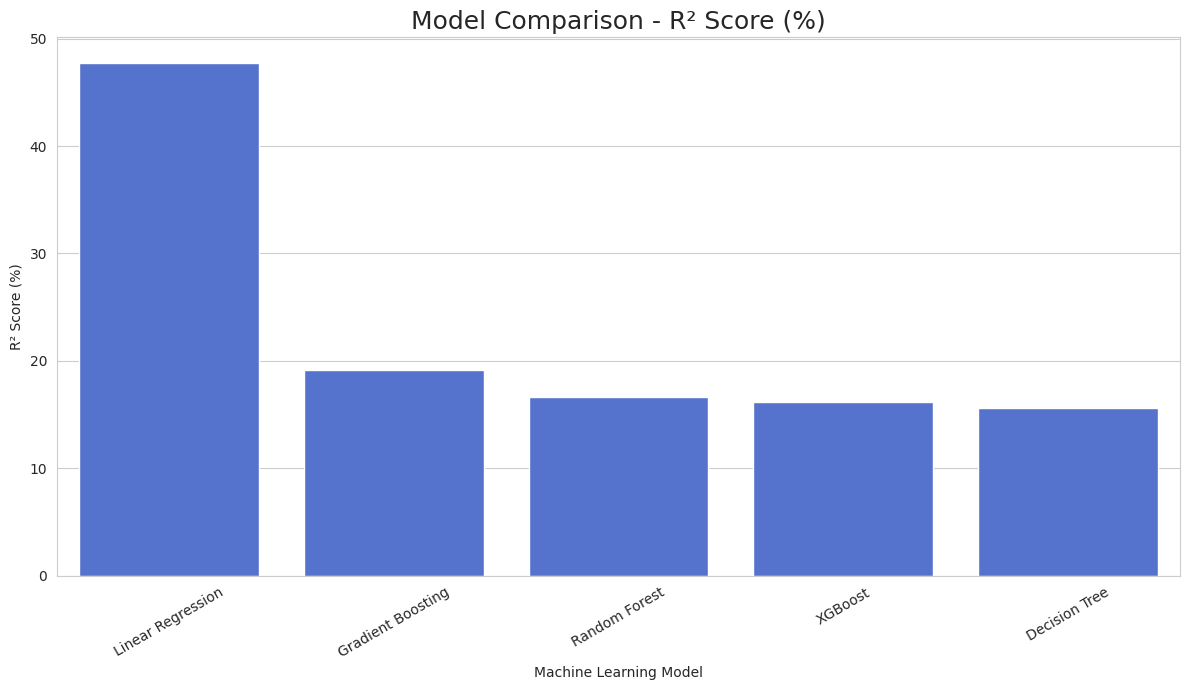

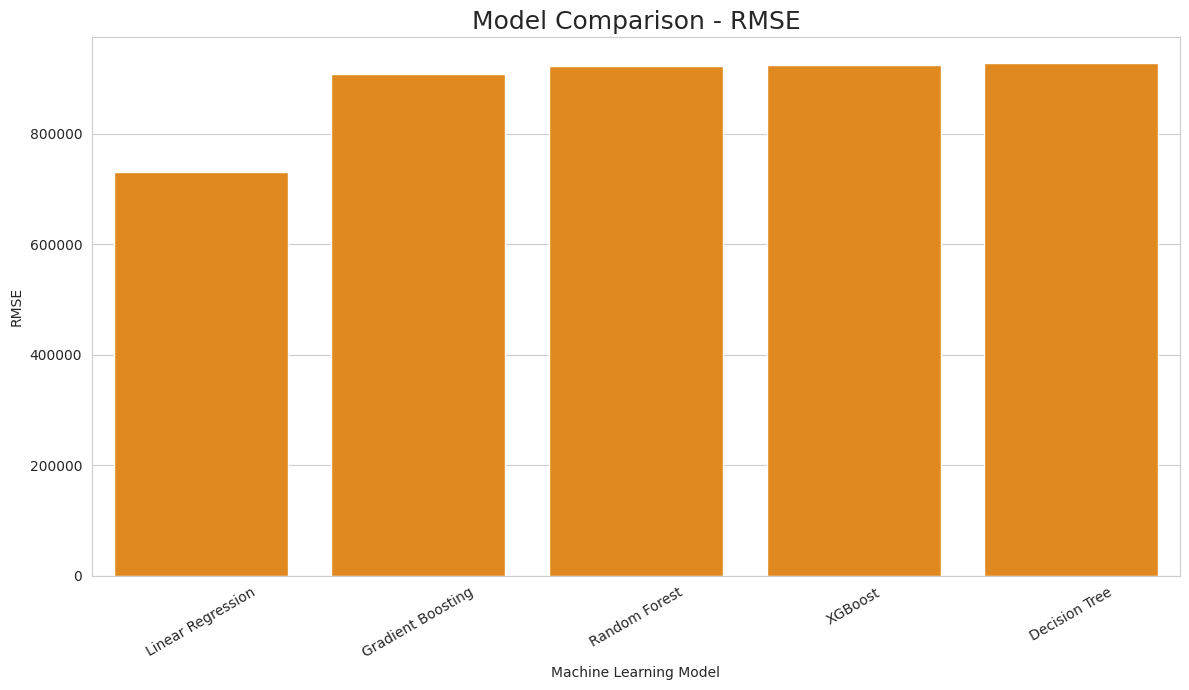

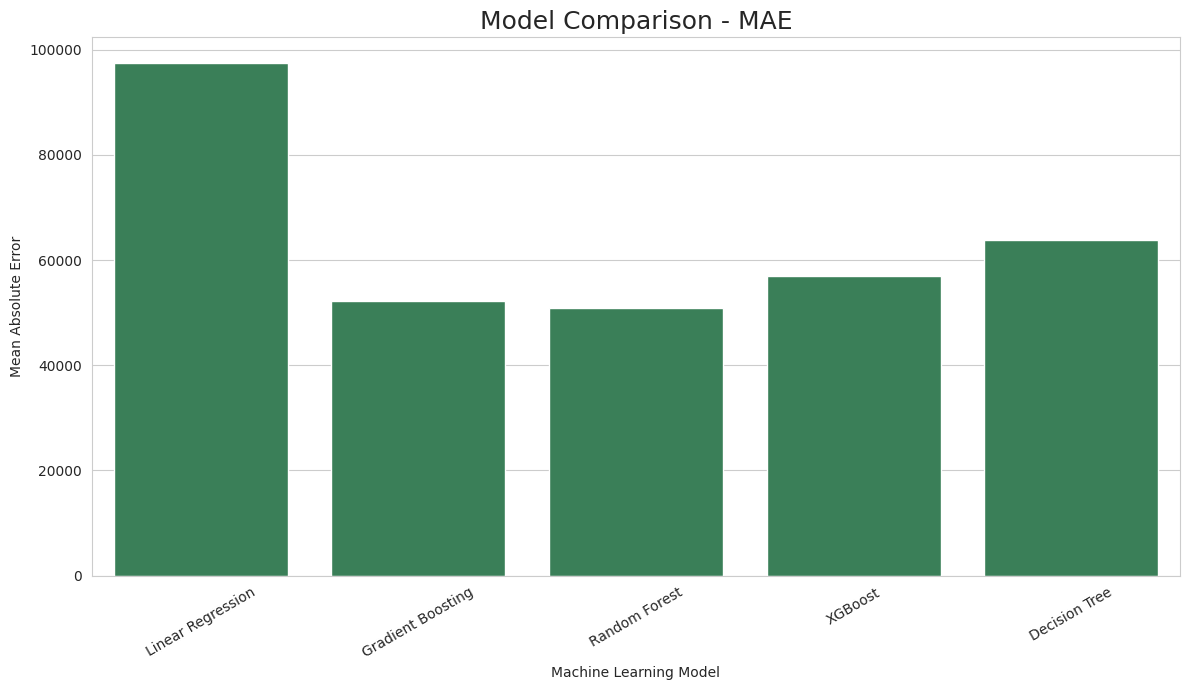

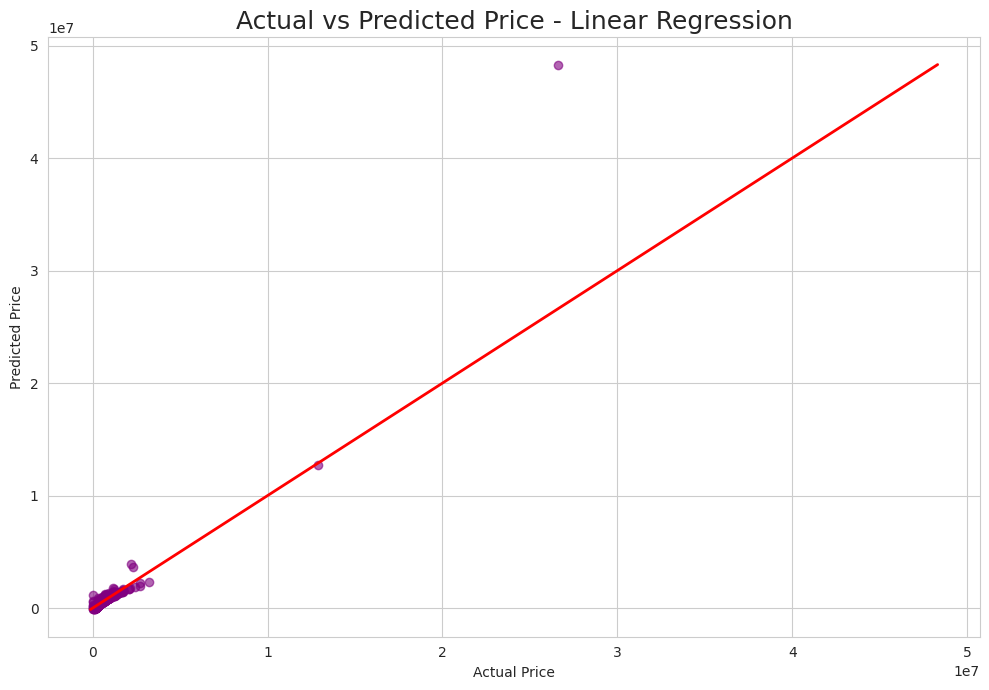

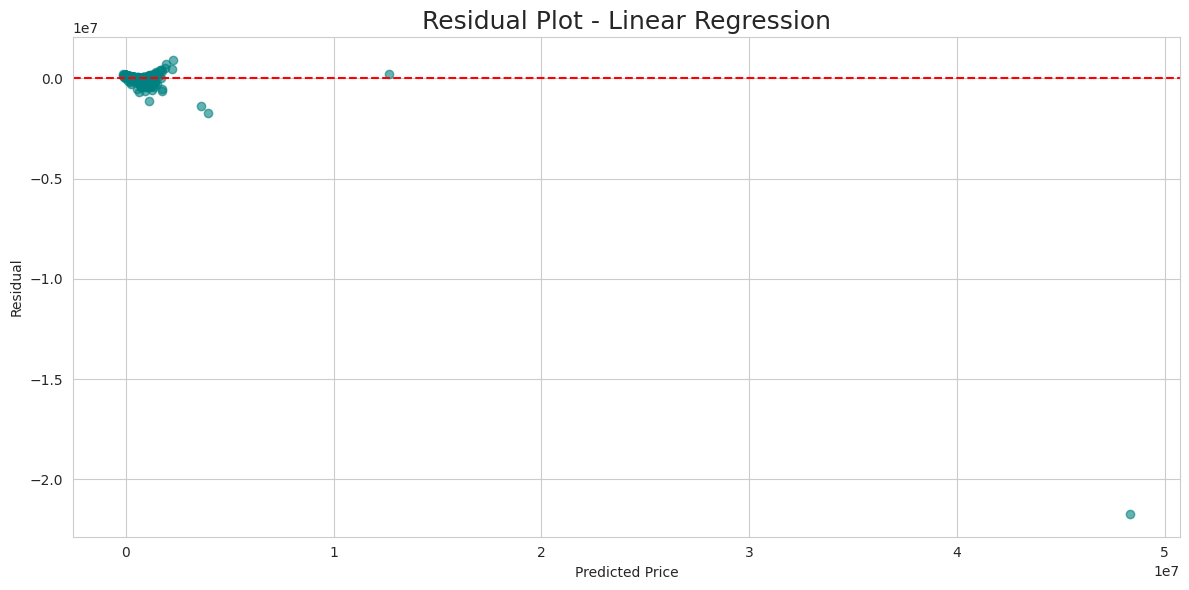


ACTUAL VS PREDICTED VALUES
    Actual Price  Predicted Price     Difference
0      544000.00     5.659141e+05  -21914.140918
1           0.00    -7.374049e+04   73740.494440
2     1712500.00     1.473921e+06  238579.366128
3      365000.00     3.582364e+05    6763.566654
4      275000.00     2.312274e+05   43772.622264
5      625000.00     6.256615e+05    -661.493817
6      453000.00     4.888861e+05  -35886.139937
7      300000.00     2.796203e+05   20379.650559
8      417985.71     4.042097e+05   13776.036090
9      672500.00     6.539675e+05   18532.538920
10     525000.00     5.907685e+05  -65768.509156
11     500000.00     7.823400e+05 -282340.043482
12     590000.00     7.185809e+05 -128580.944989
13     305000.00     2.971482e+05    7851.783426
14     210000.00     1.110590e+05   98940.982398
15     915000.00     9.094901e+05    5509.887784
16     675000.00     6.707922e+05    4207.799096
17     630000.00     5.727224e+05   57277.575846
18    1690000.00     1.438703e+06  251296

In [14]:
# Train-test split
from sklearn.model_selection import train_test_split

# Label Encoding
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


print("=" * 70)
print("DATASET LOADED")
print("=" * 70)

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nFirst 5 rows:")
print(df.head())

# ================================================================
# 3. CHECK DATA TYPES
# ================================================================

print("\n" + "=" * 70)
print("DATA TYPES")
print("=" * 70)

print(df.dtypes)

# ================================================================
# 4. CONVERT DATE COLUMN
# ================================================================

df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Extract useful information from date
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day

# Drop original date column
df.drop("date", axis=1, inplace=True)

print("\nDate converted into:")
print("year")
print("month")
print("day")

# ================================================================
# 5. CHECK MISSING VALUES
# ================================================================

print("\n" + "=" * 70)
print("MISSING VALUES")
print("=" * 70)

print(df.isnull().sum())

# ================================================================
# 6. HANDLE MISSING VALUES
# ================================================================

# Numerical columns
numeric_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

for col in numeric_columns:
    df[col] = df[col].fillna(
        df[col].median()
    )

# Categorical columns
categorical_columns = df.select_dtypes(
    include=["object"]
).columns

for col in categorical_columns:
    df[col] = df[col].fillna(
        df[col].mode()[0]
    )

print("\nMissing values after treatment:")
print(df.isnull().sum().sum())

# ================================================================
# 7. REMOVE DUPLICATES
# ================================================================

print("\nDuplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

# ================================================================
# 8. DEFINE TARGET VARIABLE
# ================================================================

# Target variable
target = "price"

X = df.drop(target, axis=1)

y = df[target]

print("\n" + "=" * 70)
print("TARGET VARIABLE")
print("=" * 70)

print("Target:", target)

print("X Shape:", X.shape)
print("y Shape:", y.shape)

# ================================================================
# 9. LABEL ENCODING
# ================================================================

print("\n" + "=" * 70)
print("LABEL ENCODING")
print("=" * 70)

label_encoders = {}

for col in X.select_dtypes(include=["object"]).columns:

    le = LabelEncoder()

    X[col] = le.fit_transform(
        X[col].astype(str)
    )

    label_encoders[col] = le

    print(
        f"{col} -> Label Encoded"
    )

print("\nEncoded Feature Data:")
print(X.head())

# ================================================================
# 10. CHECK FEATURES
# ================================================================

print("\n" + "=" * 70)
print("FEATURES USED FOR MODEL")
print("=" * 70)

print(X.columns.tolist())

# ================================================================
# 11. TRAIN TEST SPLIT
# ================================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("\n" + "=" * 70)
print("TRAIN TEST SPLIT")
print("=" * 70)

print("X_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)
print("y_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

# ================================================================
# 12. FEATURE SCALING
# ================================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature scaling completed.")

# ================================================================
# 13. CREATE MACHINE LEARNING MODELS
# ================================================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42,
            max_depth=15
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=5,
            random_state=42
        )
}

# ================================================================
# 14. XGBOOST - OPTIONAL
# ================================================================

try:

    from xgboost import XGBRegressor

    models["XGBoost"] = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    )

    print("\nXGBoost successfully loaded.")

except ImportError:

    print(
        "\nXGBoost is not installed."
    )

    print(
        "The other models will still run."
    )

# ================================================================
# 15. TRAIN ALL MODELS
# ================================================================

results = []

predictions = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print("TRAINING:", name)
    print("=" * 70)

    # ------------------------------------------------------------
    # Linear Regression uses scaled data
    # Other tree models can use original data
    # ------------------------------------------------------------

    if name == "Linear Regression":

        model.fit(
            X_train_scaled,
            y_train
        )

        y_pred = model.predict(
            X_test_scaled
        )

    else:

        model.fit(
            X_train,
            y_train
        )

        y_pred = model.predict(
            X_test
        )

    # Store predictions
    predictions[name] = y_pred

    # ------------------------------------------------------------
    # Evaluation
    # ------------------------------------------------------------

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )

    # R2 percentage
    r2_percentage = r2 * 100

    # ------------------------------------------------------------
    # Store results
    # ------------------------------------------------------------

    results.append({
        "Model": name,
        "R2 Score": r2,
        "R2 Percentage": r2_percentage,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse
    })

    # ------------------------------------------------------------
    # Print results
    # ------------------------------------------------------------

    print("\nModel:", name)

    print(
        "R2 Score:",
        round(r2, 4)
    )

    print(
        "R2 Percentage:",
        round(r2_percentage, 2),
        "%"
    )

    print(
        "MAE:",
        round(mae, 2)
    )

    print(
        "MSE:",
        round(mse, 2)
    )

    print(
        "RMSE:",
        round(rmse, 2)
    )

# ================================================================
# 16. MODEL COMPARISON
# ================================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2 Score",
    ascending=False
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.to_string(
        index=False
    )
)

# ================================================================
# 17. BEST MODEL
# ================================================================

best_model_name = results_df.iloc[0]["Model"]

best_r2 = results_df.iloc[0]["R2 Score"]

best_r2_percentage = (
    results_df.iloc[0]["R2 Percentage"]
)

print("\n" + "=" * 70)
print("BEST MODEL")
print("=" * 70)

print(
    "Best Model:",
    best_model_name
)

print(
    "R2 Score:",
    round(best_r2, 4)
)

print(
    "R2 Percentage:",
    round(best_r2_percentage, 2),
    "%"
)

# ================================================================
# 18. MODEL COMPARISON - R2 PERCENTAGE
# ================================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Percentage",
    color="royalblue"
)

plt.title(
    "Model Comparison - R² Score (%)",
    fontsize=18
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score (%)")

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

# ================================================================
# 19. MODEL COMPARISON - RMSE
# ================================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE",
    color="darkorange"
)

plt.title(
    "Model Comparison - RMSE",
    fontsize=18
)

plt.xlabel("Machine Learning Model")
plt.ylabel("RMSE")

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

# ================================================================
# 20. MODEL COMPARISON - MAE
# ================================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=results_df,
    x="Model",
    y="MAE",
    color="seagreen"
)

plt.title(
    "Model Comparison - MAE",
    fontsize=18
)

plt.xlabel("Machine Learning Model")
plt.ylabel("Mean Absolute Error")

plt.xticks(
    rotation=30
)

plt.tight_layout()
plt.show()

# ================================================================
# 21. ACTUAL VS PREDICTED - BEST MODEL
# ================================================================

best_predictions = predictions[
    best_model_name
]

plt.figure(figsize=(10, 7))

plt.scatter(
    y_test,
    best_predictions,
    color="purple",
    alpha=0.6
)

# Perfect prediction line
min_value = min(
    y_test.min(),
    best_predictions.min()
)

max_value = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    color="red",
    linewidth=2
)

plt.title(
    f"Actual vs Predicted Price - {best_model_name}",
    fontsize=18
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.tight_layout()
plt.show()

# ================================================================
# 22. RESIDUAL PLOT
# ================================================================

residuals = (
    y_test.values -
    best_predictions
)

plt.figure(figsize=(12, 6))

plt.scatter(
    best_predictions,
    residuals,
    color="teal",
    alpha=0.6
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.title(
    f"Residual Plot - {best_model_name}",
    fontsize=18
)

plt.xlabel("Predicted Price")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

# ================================================================
# 23. FEATURE IMPORTANCE
# ================================================================

best_model = models[
    best_model_name
]

if hasattr(
    best_model,
    "feature_importances_"
):

    importance = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            best_model.feature_importances_

    })

    importance = importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n" + "=" * 70)
    print("FEATURE IMPORTANCE")
    print("=" * 70)

    print(
        importance.to_string(
            index=False
        )
    )

    # Plot feature importance
    plt.figure(figsize=(12, 8))

    sns.barplot(
        data=importance.head(15),
        x="Importance",
        y="Feature",
        color="crimson"
    )

    plt.title(
        f"Top Feature Importance - {best_model_name}",
        fontsize=18
    )

    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()

# ================================================================
# 24. ACTUAL AND PREDICTED VALUES
# ================================================================

comparison = pd.DataFrame({

    "Actual Price":
        y_test.values,

    "Predicted Price":
        best_predictions,

    "Difference":
        y_test.values - best_predictions

})

print("\n" + "=" * 70)
print("ACTUAL VS PREDICTED VALUES")
print("=" * 70)

print(
    comparison.head(20)
)

# ================================================================
# 25. FINAL SUMMARY
# ================================================================

print("\n" + "=" * 70)
print("FINAL MACHINE LEARNING SUMMARY")
print("=" * 70)

print(
    "Best Model        :",
    best_model_name
)

print(
    "R2 Score          :",
    round(best_r2, 4)
)

print(
    "R2 Percentage     :",
    round(best_r2_percentage, 2),
    "%"
)

best_row = results_df.iloc[0]

print(
    "MAE               :",
    round(best_row["MAE"], 2)
)

print(
    "RMSE              :",
    round(best_row["RMSE"], 2)
)

print(
    "Training Samples  :",
    len(X_train)
)

print(
    "Testing Samples   :",
    len(X_test)
)

print("\nMachine Learning Pipeline Completed Successfully!")

## Thank you...pls upvote!!!!!